In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from math import pi
import re
import json
from pathlib import Path


# Set style for better visualizations
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11



# ============================================================================
# CONFIGURATION
# ============================================================================
SEQ_LEN = 512  # Your sequence length
BATCH_SIZE_PER_GPU = 16
TOTAL_STEPS = 480
DP_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 8
TOKENS_PER_STEP = BATCH_SIZE_PER_GPU * DP_SIZE * SEQ_LEN
BATCH_SIZE = TOKENS_PER_STEP * GRADIENT_ACCUMULATION_STEPS
TOTAL_TOKENS_PROCESSED = TOTAL_STEPS* BATCH_SIZE
LOSS_LOG_INTERVAL = 4

print(f"Configuration:")
print(f"  Sequence Length: {SEQ_LEN}")
print(f"  Batch Size per GPU: {BATCH_SIZE_PER_GPU}")
print(f"  Data Parallel Size: {DP_SIZE}")
print(f"  Tokens per Step: {TOKENS_PER_STEP}")
print(f"  Loss Log Interval: {LOSS_LOG_INTERVAL} steps\n")
print(f"  Sequence Length: {SEQ_LEN}")
print(f"  Batch Size per GPU: {BATCH_SIZE_PER_GPU}")
print(f"  Data Parallel Size: {DP_SIZE}")
print(f"  Tokens per Step: {TOKENS_PER_STEP}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Total Tokens Processed: {TOTAL_TOKENS_PROCESSED}")

Configuration:
  Sequence Length: 512
  Batch Size per GPU: 16
  Data Parallel Size: 4
  Tokens per Step: 32768
  Loss Log Interval: 4 steps

  Sequence Length: 512
  Batch Size per GPU: 16
  Data Parallel Size: 4
  Tokens per Step: 32768
  Batch Size: 262144
  Total Tokens Processed: 125829120


In [40]:
def extract_logs(text):
    microsteps = []
    optimizer_buffer = {}

    for line in text:
        if "[Rank" not in line:
            continue

        parts = line.split('|')[1:]
        metrics = {}

        # ----------------------------
        # Parse key:value pairs
        # ----------------------------
        for p in parts:
            if ':' in p:
                key, val = p.split(':', 1)
                key = key.strip()
                try:
                    metrics[key] = float(val.strip())
                except ValueError:
                    continue

        # ----------------------------
        # Capture optimizer comm separately
        # ----------------------------
        if 'optimizer_allgather' in metrics:
            optimizer_buffer = {
                "optimizer_allgather": metrics.get("optimizer_allgather", 0),
                "optimizer_gradients": metrics.get("optimizer_gradients", 0),
                "optimizer_step": metrics.get("optimizer_step", 0)
            }
            continue  # wait for next microstep

        # ----------------------------
        # Process microstep
        # ----------------------------
        if 'fwd_microstep' in metrics:

            fwd = metrics.get("fwd_microstep", 0)
            bwd = metrics.get("bwd_microstep", 0)
            bwd_inner = metrics.get("bwd_inner_microstep", 0)
            bwd_allreduce = metrics.get("bwd_allreduce_microstep", 0)
            step = metrics.get("step_microstep", 0)

            # ----------------------------
            # Attach optimizer comm if exists
            # ----------------------------
            opt_allgather = optimizer_buffer.get("optimizer_allgather", 0) + optimizer_buffer.get("optimizer_step",0)

            # ----------------------------
            # Core metrics
            # ----------------------------
            real_compute = fwd + bwd_inner

            real_comm = bwd_allreduce + opt_allgather

            total_time = fwd + bwd + step  + opt_allgather

            total_effective = real_compute + real_comm + step

            # ----------------------------
            # Derived metrics
            # ----------------------------
            metrics.update({
                "real_compute_ms": real_compute,
                "real_comm_ms": real_comm,
                "total_microstep_time": total_time,
                "total_effective_time": total_effective,

                "compute_pct": (real_compute / total_effective)*100 if total_effective > 0 else 0,
                "comm_pct": (real_comm / total_effective)*100 if total_effective > 0 else 0,

                "compute_comm_ratio": real_compute / (real_comm + 1e-6),

                # how much of observed time is useful compute
                "compute_efficiency": (real_compute / total_time) * 100 if total_time > 0 else 0,

                "total_time_s": total_time / 1000.0,
                'optimizer': opt_allgather
            })

            microsteps.append(metrics)

            # reset optimizer buffer after use
            optimizer_buffer = {}

    return microsteps

In [41]:
# ============================================================================
# LOAD DATA
# ============================================================================
json_files = {
    0: "../results/stage_0_metrics.json",
    1: "../results/stage_1_metrics.json",
    2: "../results/stage_2_metrics.json",
    3: "../results/stage_3_metrics.json"
}

logs = ['stage_0_0-480.log',
        'stage_1_0-480.log',
        'stage_2_0-480.log',
        'stage_3_0-480.log']

# Load JSON metrics
all_metrics = []
for i in range(0,4):
    try:
        df_temp = pd.read_json(json_files[i])
        df_temp['stage'] = i
        all_metrics.append(df_temp)
        print(f"Successfully loaded stage {i} metrics: {len(df_temp)} records")
    except Exception as e:
        print(f"Error loading stage {i} JSON: {e}")
        all_metrics.append(pd.DataFrame(columns=['stage', 'step', 'iteration_time_ms', 'throughput_tps', 
                                                  'peak_gb', 'alloc_gb', 'reserved_gb', 'gpu_util']))

df_all = pd.concat(all_metrics, ignore_index=True)

df_all.drop(["compute_ms", "comm_ms", "comm_pct",'fwd_ms', 'bwd_ms','iteration_time_ms'], axis=1, inplace=True, errors='ignore')

Successfully loaded stage 0 metrics: 120 records
Successfully loaded stage 1 metrics: 120 records
Successfully loaded stage 2 metrics: 121 records
Successfully loaded stage 3 metrics: 120 records


In [42]:
# Process microstep logs
micro_all = []
optimizer_allgather_all = []
for stage_id in range(0, 4):
    try:
        with open(logs[stage_id]) as f:
            data = f.readlines()
            microstep = extract_logs(data)
            df_microstep = pd.DataFrame(microstep)
            if not df_microstep.empty:
                df_microstep["stage"] = stage_id
                if 'microstep_idx' not in df_microstep.columns and 'step' not in df_microstep.columns:
                    df_microstep['step'] = range(len(df_microstep))
                micro_all.append(df_microstep)
                print(f"Stage {stage_id}: Loaded {len(df_microstep)} microstep records")
            else:
                print(f"Stage {stage_id}: No microstep data found")

         
    except Exception as e:
        print(f"Error loading stage {stage_id} log: {e}")

if micro_all:
    df_micro_all = pd.concat(micro_all, ignore_index=True)
    print(f"\nTotal microstep records: {len(df_micro_all)}")
else:
    df_micro_all = pd.DataFrame()
    print("WARNING: No microstep data loaded!")

Stage 0: Loaded 480 microstep records
Stage 1: Loaded 480 microstep records
Stage 2: Loaded 480 microstep records
Stage 3: Loaded 480 microstep records

Total microstep records: 1920


In [43]:
# ============================================================================
# MERGE AND PROCESS DATA
# ============================================================================
print("\nAvailable columns in df_all:", df_all.columns.tolist())
if not df_micro_all.empty:
    print("Available columns in df_micro_all:", df_micro_all.columns.tolist())

if not df_micro_all.empty:
    micro_per_step = 4
    df_micro_sampled = df_micro_all.iloc[::micro_per_step].copy() if len(df_micro_all) > micro_per_step else df_micro_all.copy()
    
    # Map columns based on what's actually available
    rename_dict = {}
    if 'real_compute_ms' in df_micro_sampled.columns:
        rename_dict['real_compute_ms'] = 'compute_ms'
    if 'real_comm_ms' in df_micro_sampled.columns:
        rename_dict['real_comm_ms'] = 'comm_ms'
    if 'real_comm_pct' in df_micro_sampled.columns:
        rename_dict['real_comm_pct'] = 'comm_pct'
    if 'fwd_microstep' in df_micro_sampled.columns:
        rename_dict['fwd_microstep'] = 'fwd_ms'
    if 'bwd_microstep' in df_micro_sampled.columns:
        rename_dict['bwd_microstep'] = 'bwd_ms'
    
    df_micro_sampled = df_micro_sampled.rename(columns=rename_dict)
    
    cols =  ['compute_comm_ratio',
                               'compute_pct',
                                 'comm_ms',
                                   'compute_ms', 
                                   'total_microstep_time',
                                   'total_effective_time',
                                    'total_time_s',
                                'comm_pct', 
                               'fwd_ms', 
                               'bwd_ms', 
                               'compute_efficiency']
    # Merge with main dataframe
    micro_cols = [c for c in cols
                  if c in df_micro_sampled.columns]
    
    if micro_cols:
        df_all_updated = df_all.merge(
            df_micro_sampled[['stage', 'step'] + micro_cols],
            on=['stage', 'step'],
            how='left',
            suffixes=('', '_micro')
        )
        
        # Update columns with microstep data where available
        for col in cols:
            if f"{col}_micro" in df_all_updated.columns and col in df_all_updated.columns:
                df_all_updated[col] = df_all_updated[f"{col}_micro"].fillna(df_all_updated[col])
                if f"{col}_micro" in df_all_updated.columns:
                    df_all_updated.drop(columns=[f"{col}_micro"], inplace=True)
        
        df_all = df_all_updated


Available columns in df_all: ['stage', 'step', 'loss', 'lr', 'step_ms', 'throughput_tps', 'gpu_util', 'temp_c', 'alloc_gb', 'reserved_gb', 'peak_gb']
Available columns in df_micro_all: ['fwd_microstep', 'bwd_microstep', 'bwd_inner_microstep', 'bwd_allreduce_microstep', 'step_microstep', 'real_compute_ms', 'real_comm_ms', 'total_microstep_time', 'total_effective_time', 'compute_pct', 'comm_pct', 'compute_comm_ratio', 'compute_efficiency', 'total_time_s', 'optimizer', 'stage', 'step']


In [44]:
s = df_micro_all.groupby('stage').mean()
s['compute_comm_ratio'] = s['real_compute_ms']/s['real_comm_ms']
s['compute_pct'] = (s['real_compute_ms'] / s['total_effective_time'])*100
s['comm_pct'] = (s['real_comm_ms'] / s['total_effective_time'])*100
s['compute_efficiency'] =  (s['real_compute_ms'] / (s['real_comm_ms']+ 1e-6))*100
s['comm_overhead_pct'] = (s['real_comm_ms'] / s['total_microstep_time']) * 100
s['stage'] =s.index
s

,fwd_microstep,bwd_microstep,bwd_inner_microstep,bwd_allreduce_microstep,step_microstep,real_compute_ms,real_comm_ms,total_microstep_time,total_effective_time,compute_pct,comm_pct,compute_comm_ratio,compute_efficiency,total_time_s,optimizer,step,comm_overhead_pct,stage
stage,,,,,,,,,,,,,,,,,,
0,311.611646,1822.894604,493.567000,1328.996000,1.246063,805.178646,1328.996000,2135.752312,2135.420708,37.705855,62.235792,0.605855,60.585483,2.135752,0.000000,239.5,62.226130,0
1,316.446417,1819.868021,499.037958,1320.426563,84.058958,815.484375,1402.865958,2302.812792,2302.409292,35.418741,60.930346,0.581299,58.129885,2.302813,82.439396,239.5,60.919670,1
2,306.160479,11089.767312,495.342375,10594.005625,86.376771,801.502854,10676.468750,11564.767687,11564.348375,6.930809,92.322268,0.075072,7.507191,11.564768,82.463125,239.5,92.318921,2
3,3186.770812,5831.694271,482.413187,5348.640146,120.741083,3669.184000,5348.640146,9139.206167,9138.565229,40.150548,58.528226,0.686003,68.600315,9.139206,0.000000,239.5,58.524122,3


In [51]:
s = df_micro_all.groupby('stage').sum()
s

,fwd_microstep,bwd_microstep,bwd_inner_microstep,bwd_allreduce_microstep,step_microstep,real_compute_ms,real_comm_ms,total_microstep_time,total_effective_time,compute_pct,comm_pct,compute_comm_ratio,compute_efficiency,total_time_s,optimizer,step
stage,,,,,,,,,,,,,,,,
0,149573.59,874989.41,236912.16,637918.08,598.11,386485.75,637918.08,1025161.11,1025001.94,42416.182747,5576.640808,1.676011e+07,42400.260386,1025.16111,0.00,114960
1,151894.28,873536.65,239538.22,633804.75,40348.30,391432.50,673375.66,1105350.14,1105156.46,42376.564765,5303.712276,1.647481e+07,42357.240024,1105.35014,39570.91,114960
2,146957.03,5323088.31,237764.34,5085122.70,41460.85,384721.37,5124705.00,5551088.49,5550887.22,3330.277799,44344.531983,3.605127e+01,3330.157847,5551.08849,39582.30,114960
3,1529649.99,2799213.25,231558.33,2567347.27,57955.72,1761208.32,2567347.27,4386818.96,4386511.31,19280.652449,28156.911684,3.292503e+02,19279.297112,4386.81896,0.00,114960


In [52]:
# Plot 3: Communication Overhead Bar Chart
if not s.empty:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(s["stage"], s["comm_pct"], 
                   color='mediumseagreen', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("Communication %", fontsize=12)
    plt.title("Communication Overhead vs ZeRO Stage (from Microstep Data)", fontsize=14, fontweight='bold')
    plt.xticks(s["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, s["comm_pct"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('03_comm_overhead_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

KeyError: 'stage'

<Figure size 1000x600 with 0 Axes>


Stage 0 - Loss samples: 120 records

Stage 1 - Loss samples: 120 records

Stage 2 - Loss samples: 120 records

Stage 3 - Loss samples: 120 records

TABLE 0: Loss Convergence Comparison (Every 50 Steps)
 step  loss_stage_0  loss_stage_1  loss_stage_2  loss_stage_3
  0.0       10.9641       10.9641       10.9641       10.9641
  4.0       10.9558       10.9558       10.9558       10.9558
  8.0       10.9648       10.9631       10.9631       10.9630
 12.0       10.9536       10.9521       10.9521       10.9520
 16.0       10.9566       10.9500       10.9500       10.9492
 20.0       10.9496       10.9429       10.9429       10.9419
 24.0       10.7977       10.5433       10.4740       10.5329
 28.0       10.7943       10.5535       10.4815       10.5381
 32.0       10.5182       10.2550       10.2212       10.2277
 36.0       10.4828       10.2216       10.1863       10.1879
 40.0       10.3975       10.1461       10.1218       10.1027
 44.0       10.4103       10.1615       10.1378      

/tmp/ipykernel_191251/751809320.py:59: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined_loss = combined_loss.fillna(method='ffill')


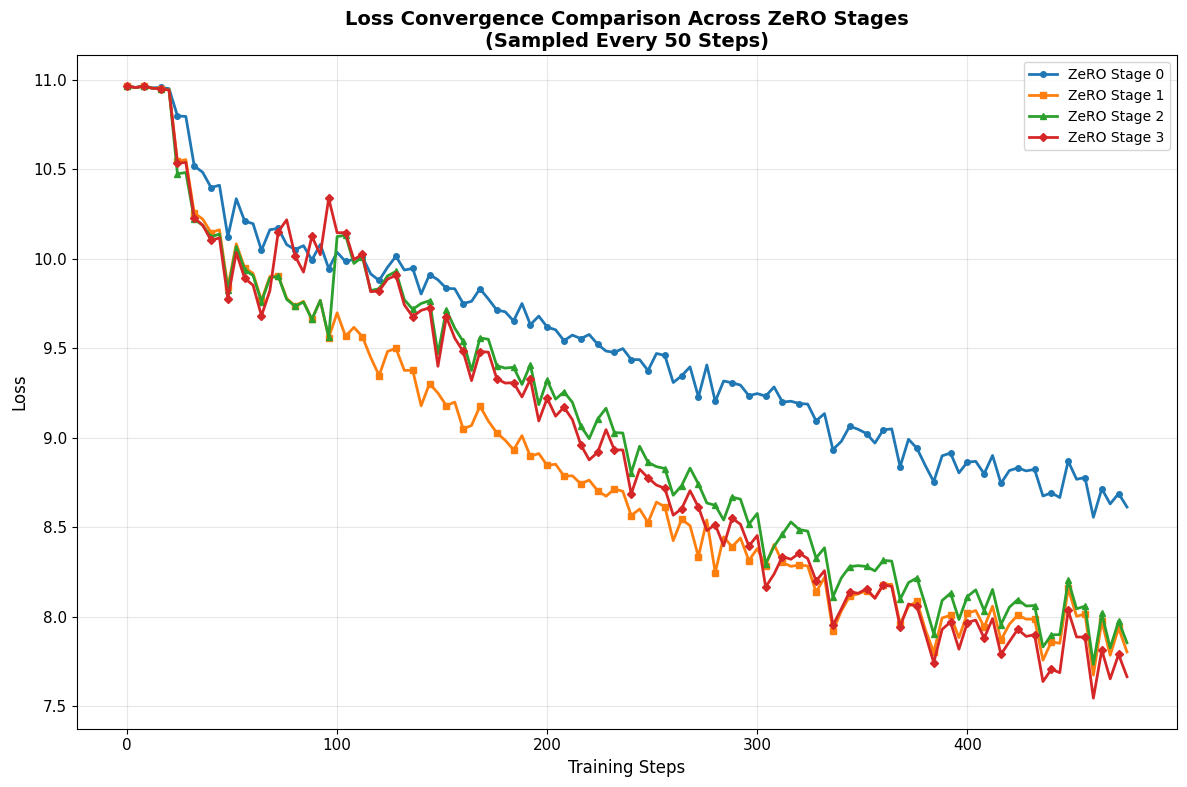

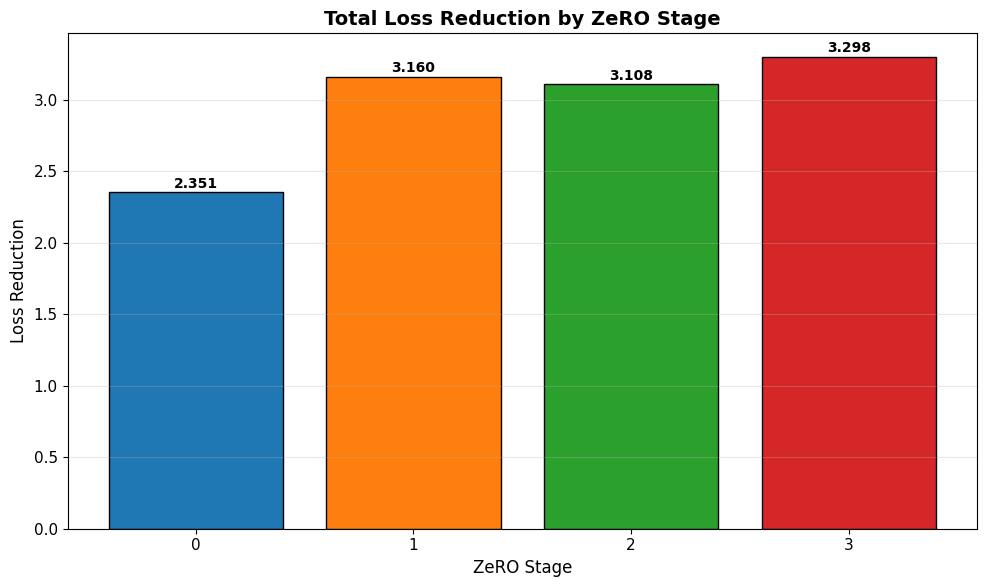

In [53]:

# ============================================================================
# LOSS VS STEP TABLE (Everya 50 Steps)
# ============================================================================
def sample_loss_at_intervals(df, stage_id, interval=50):
    """Sample loss at regular step intervals"""
    if 'loss' not in df.columns or df.empty:
        return pd.DataFrame(columns=['stage', 'step', 'loss'])
    
    stage_df = df[df['stage'] == stage_id].copy()
    
    if stage_df.empty:
        return pd.DataFrame(columns=['stage', 'step', 'loss'])
    
    stage_df = stage_df.sort_values('step')
    
    # Get steps at regular intervals
    max_step = stage_df['step'].max()
    sampled_steps = list(range(0, max_step + 1, interval))
    
    # Sample loss at each interval
    sampled_data = []
    for step in sampled_steps:
        closest_idx = (stage_df['step'] - step).abs().idxmin()
        closest_row = stage_df.loc[closest_idx]
        
        sampled_data.append({
            'stage': stage_id,
            'step': closest_row['step'],
            'loss': closest_row['loss']
        })
    
    return pd.DataFrame(sampled_data)

# Create loss table for all stages
loss_tables = []
for stage_id in range(4):
    loss_df = sample_loss_at_intervals(df_all, stage_id, LOSS_LOG_INTERVAL)
    if not loss_df.empty:
        loss_tables.append(loss_df)
        print(f"\nStage {stage_id} - Loss samples: {len(loss_df)} records")

# Create combined loss table
if loss_tables:
    # Initialize with first stage
    combined_loss = loss_tables[0][['step', 'loss']].copy()
    combined_loss = combined_loss.rename(columns={'loss': f'loss_stage_{int(loss_tables[0]["stage"].iloc[0])}'})
    
    # Add remaining stages
    for loss_df in loss_tables[1:]:
        stage = int(loss_df["stage"].iloc[0])
        temp_df = loss_df[['step', 'loss']].copy()
        temp_df = temp_df.rename(columns={'loss': f'loss_stage_{stage}'})
        combined_loss = pd.merge(combined_loss, temp_df, on='step', how='outer')
    
    # Sort by step and fill missing values
    combined_loss = combined_loss.sort_values('step').reset_index(drop=True)
    
    # Forward fill missing values (if a stage doesn't have loss at exact step)
    combined_loss = combined_loss.fillna(method='ffill')
    
    # ============================================================================
    # PRINT TABLE 0: Loss Convergence Comparison
    # ============================================================================
    print("\n" + "="*120)
    print("TABLE 0: Loss Convergence Comparison (Every 50 Steps)")
    print("="*120)
    print(combined_loss.round(4).to_string(index=False))
    
    # Save to CSV
    combined_loss.to_csv("table0_loss_convergence.csv", index=False)
    print("\n✓ Loss table saved to 'table0_loss_convergence.csv'")
    
    # ============================================================================
    # ADDITIONAL LOSS METRICS TABLE
    # ============================================================================
    print("\n" + "="*120)
    print("TABLE 0a: Loss Convergence Metrics")
    print("="*120)
    
    convergence_data = []
    for stage_id in range(4):
        stage_loss_df = loss_tables[stage_id] if stage_id < len(loss_tables) else pd.DataFrame()
        if not stage_loss_df.empty:
            initial_loss = stage_loss_df['loss'].iloc[0]
            final_loss = stage_loss_df['loss'].iloc[-1]
            loss_reduction = initial_loss - final_loss
            loss_reduction_pct = (loss_reduction / initial_loss) * 100
            
            # Calculate steps to reach 90% of final loss
            target_loss = initial_loss - 0.9 * loss_reduction
            steps_to_90 = None
            for idx, row in stage_loss_df.iterrows():
                if row['loss'] <= target_loss:
                    steps_to_90 = row['step']
                    break
            
            convergence_data.append({
                'ZeRO Stage': stage_id,
                'Initial Loss': round(initial_loss, 4),
                'Final Loss': round(final_loss, 4),
                'Loss Reduction': round(loss_reduction, 4),
                'Reduction %': round(loss_reduction_pct, 2),
                'Steps to 90% Conv': steps_to_90 if steps_to_90 else 'N/A'
            })
    
    convergence_df = pd.DataFrame(convergence_data)
    print(convergence_df.to_string(index=False))
    convergence_df.to_csv("table0_loss_convergence_metrics.csv", index=False)
    
    # ============================================================================
    # PLOT LOSS CURVES
    # ============================================================================
    plt.figure(figsize=(12, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    markers = ['o', 's', '^', 'D']
    
    for idx, loss_df in enumerate(loss_tables):
        stage = int(loss_df['stage'].iloc[0])
        plt.plot(loss_df['step'], loss_df['loss'], 
                marker=markers[idx % len(markers)], 
                markersize=4,
                linewidth=2, 
                label=f'ZeRO Stage {stage}',
                color=colors[idx % len(colors)],
                markevery=2)
    
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss Convergence Comparison Across ZeRO Stages\n(Sampled Every 50 Steps)', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('00_loss_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Plot loss reduction bar chart
    plt.figure(figsize=(10, 6))
    bars = plt.bar(convergence_df['ZeRO Stage'], convergence_df['Loss Reduction'], 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], 
                  edgecolor='black')
    plt.xlabel('ZeRO Stage', fontsize=12)
    plt.ylabel('Loss Reduction', fontsize=12)
    plt.title('Total Loss Reduction by ZeRO Stage', fontsize=14, fontweight='bold')
    plt.xticks(convergence_df['ZeRO Stage'])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, convergence_df['Loss Reduction']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('00_loss_reduction.png', dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("\n⚠️ No loss data available in the JSON files")
    print("Make sure your JSON files contain a 'loss' column")

In [54]:
summary_mean = df_all.groupby("stage").agg({
    "fwd_ms": "mean",
    "bwd_ms": "mean",
    "compute_ms": "mean",
    "comm_ms": "mean",
    "comm_pct": "mean",
    "compute_pct": "mean",
    "compute_comm_ratio": "mean",
    "compute_efficiency": "mean",
    "throughput_tps": "mean",
    "gpu_util": "mean",
    "step_ms": "mean"
}).reset_index()

summary_mean["avg_microstep_time_s"] = summary_mean["step_ms"] / 1000.0


print("\n" + "="*120)
print("TABLE 1: Per-Step Mean Performance")
print("="*120)

table1_cols = [
    "stage", "fwd_ms", "bwd_ms", "compute_ms", "comm_ms",
    "comm_pct", "avg_microstep_time_s",
    "compute_comm_ratio", "throughput_tps", "gpu_util"
]

table1 = summary_mean[table1_cols].round(5)
print(table1.to_string(index=False))



TABLE 1: Per-Step Mean Performance
 stage     fwd_ms      bwd_ms  compute_ms     comm_ms  comm_pct  avg_microstep_time_s  compute_comm_ratio  throughput_tps  gpu_util
     0  313.63933   494.06175   807.37417     0.02125   0.00261               0.00230         39632.53689    2.539736e+06  98.65833
     1  317.57058   499.45692   816.62758     0.02158   0.00263               0.00208         39261.06136    2.506467e+06  98.81667
     2  309.83458 11098.30450   813.82833 10593.90433  92.87631               0.00195             0.07683    1.837608e+05  99.92562
     3 3247.55083  5838.93067  3737.14300  5348.69967  58.92702               0.00279             0.69866    2.344492e+05  99.20833


In [55]:
summary_total = df_micro_all.groupby("stage").agg({
    "real_compute_ms": "sum",
    "real_comm_ms": "sum"
}).reset_index()

# Total training time (already seconds → DO NOT divide again)
summary_total["total_training_time_s"] = (
    df_micro_all.groupby("stage")["total_time_s"].sum().values
)

# Rename for clean table output
summary_total = summary_total.rename(columns={
    "real_compute_ms": "compute_ms",
    "real_comm_ms": "comm_ms"
})

# Tokens processed
summary_total["total_token_processed"] = TOTAL_TOKENS_PROCESSED

# Real throughput
summary_total["avg_throughput"] = (
    summary_total["total_token_processed"] /
    summary_total["total_training_time_s"]
)

# ----------------------------
# PRINT TABLE
# ----------------------------
print("\n" + "="*70)
print("TABLE 2: Total Training Cost")
print("="*70)

table2_cols = [
    "stage",
    "total_training_time_s",
    "compute_ms",
    "comm_ms",
    "avg_throughput"
]

table2 = summary_total[table2_cols].round(5)
print(table2.to_string(index=False))


TABLE 2: Total Training Cost
 stage  total_training_time_s  compute_ms    comm_ms  avg_throughput
     0             1025.16111   386485.75  637918.08    122740.82461
     1             1105.35014   391432.50  673375.66    113836.43558
     2             5551.08849   384721.37 5124705.00     22667.46787
     3             4386.81896  1761208.32 2567347.27     28683.45404


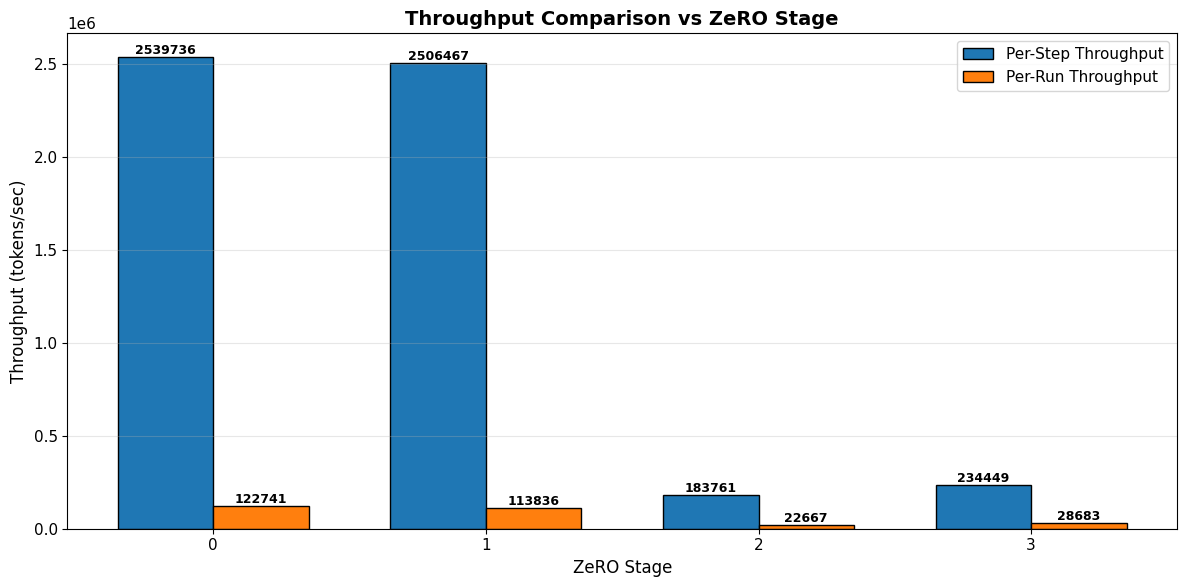

In [56]:
plt.figure(figsize=(12, 6))

stages = summary_mean["stage"].values
x = np.arange(len(stages))
width = 0.35

# Get values safely
mean_vals = summary_mean["throughput_tps"].values
total_vals = summary_total["avg_throughput"].values

# Bars
bars1 = plt.bar(x - width/2, mean_vals, width,
                label="Per-Step Throughput", edgecolor='black')

bars2 = plt.bar(x + width/2, total_vals, width,
                label="Per-Run Throughput", edgecolor='black')

# Labels
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Throughput (tokens/sec)", fontsize=12)
plt.title("Throughput Comparison vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(x, stages)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Annotate bars
def annotate(bars):
    for bar in bars:
        val = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 val,
                 f'{val:.0f}',
                 ha='center',
                 va='bottom',
                 fontsize=9,
                 fontweight='bold')

annotate(bars1)
annotate(bars2)

plt.tight_layout()
plt.savefig('01_throughput_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# ============================================================================
# CREATE SUMMARY STATISTICS
# ============================================================================
agg_dict = {
    "total_microstep_time": "mean",
    "throughput_tps": "mean",
    "peak_gb": "max",
    "alloc_gb": "mean",
    "reserved_gb": "mean",
    "temp_c": "mean",
    "gpu_util": "mean",
    "compute_ms": "sum",
    "comm_ms": "sum",
    "comm_pct": "mean", 
    "fwd_ms": "sum",
    "bwd_ms": "sum",
    "step_ms": "sum",
    "compute_pct": "mean",
    "compute_efficiency": "mean",
    "compute_comm_ratio": "mean"

}

summary = df_all.groupby("stage").agg(agg_dict).reset_index()

# true runtime
summary["total_training_time_s"] = (
    df_micro_all.groupby("stage")["total_time_s"].sum() 
)

# microstep accumulated time
summary["avg_microstep_time_s"] = (
    df_micro_all.groupby("stage")["total_microstep_time"].mean() / 1000.0
)

# # Microstep communication summary
# if not df_micro_all.empty and 'real_comm_pct' in df_micro_all.columns:
#     micro_comm_summary = df_micro_all.groupby("stage").agg({
#         "real_comm_pct": "mean"
#     }).reset_index()
#     micro_comm_summary.columns = ["stage", "comm_pct_from_microstep"]
# else:
#     micro_comm_summary = pd.DataFrame({"stage": [0,1,2,3], "comm_pct_from_microstep": [0,0,0,0]})


summary

,stage,total_microstep_time,throughput_tps,peak_gb,alloc_gb,reserved_gb,temp_c,gpu_util,compute_ms,comm_ms,comm_pct,fwd_ms,bwd_ms,step_ms,compute_pct,compute_efficiency,compute_comm_ratio,total_training_time_s,avg_microstep_time_s
0,0,807.741333,2.539736e+06,10.341675,1.676796,9.621549,67.191667,98.658333,96884.90,2.55,0.002610,37636.72,59287.41,275.820547,99.992401,99.954566,39632.536886,1025.16111,2.135752
1,1,817.069333,2.506467e+06,11.644409,1.989229,10.849089,69.150000,98.816667,97995.31,2.59,0.002631,38108.47,59934.83,249.139775,99.992246,99.945946,39261.061365,1105.35014,2.302813
2,2,11408.183333,1.837608e+05,10.110000,1.192059,9.351510,59.756198,99.925620,97659.40,1271268.52,92.876315,37180.15,1331796.54,235.661823,7.123297,7.123043,0.076827,5551.08849,11.564768
3,3,9086.528833,2.344492e+05,10.601440,1.521060,9.882575,55.150000,99.208333,448457.16,641843.96,58.927015,389706.10,700671.68,334.869873,41.072463,41.069576,0.698659,4386.81896,9.139206



TABLE 2: Memory Scaling Analysis
 ZeRO Stage  Peak VRAM (GB)  Allocated VRAM (GB)  Reserved VRAM (GB)  Model Size (M params)  Memory Reduction (%)
          0           10.34                 1.68                9.62                  51.21                  0.00
          1           11.64                 1.99               10.85                  51.21                -12.60
          2           10.11                 1.19                9.35                  51.21                  2.24
          3           10.60                 1.52                9.88                  26.05                 -2.51


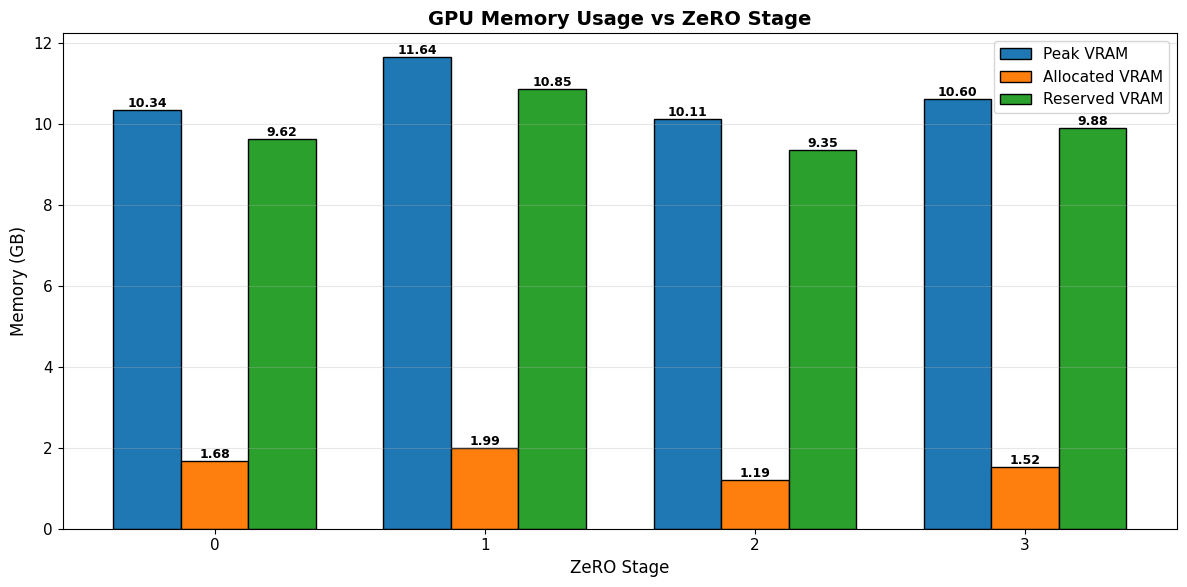

In [58]:

# ============================================================================
# TABLE 2: Memory Scaling Analysis
# ============================================================================
print("\n" + "="*120)
print("TABLE 2: Memory Scaling Analysis")
print("="*120)

if not summary.empty and 0 in summary['stage'].values:
    baseline_memory = summary[summary["stage"] == 0]["peak_gb"].values[0] if len(summary[summary["stage"] == 0]["peak_gb"].values) > 0 else 0
    
    table2 = summary[["stage", "peak_gb", "alloc_gb", "reserved_gb"]].copy()
    table2["model_params_m"] = [51.21, 51.21, 51.21, 26.05]  # From profiler output
    if baseline_memory > 0:
        table2["memory_reduction_pct"] = ((baseline_memory - table2["peak_gb"]) / baseline_memory) * 100
    else:
        table2["memory_reduction_pct"] = 0
    
    table2.columns = ["ZeRO Stage", "Peak VRAM (GB)","Allocated VRAM (GB)","Reserved VRAM (GB)", "Model Size (M params)", "Memory Reduction (%)"]
    print(table2.round(2).to_string(index=False))


plt.figure(figsize=(12, 6))

stages = summary["stage"].values
x = np.arange(len(stages))
width = 0.25

peak = summary["peak_gb"].values
alloc = summary["alloc_gb"].values
reserved = summary["reserved_gb"].values

# Bars
bars1 = plt.bar(x - width, peak, width, label="Peak VRAM", edgecolor='black')
bars2 = plt.bar(x, alloc, width, label="Allocated VRAM", edgecolor='black')
bars3 = plt.bar(x + width, reserved, width, label="Reserved VRAM", edgecolor='black')

# Labels
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Memory (GB)", fontsize=12)
plt.title("GPU Memory Usage vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(x, stages)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Annotate
def annotate(bars):
    for bar in bars:
        val = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 val,
                 f'{val:.2f}',
                 ha='center',
                 va='bottom',
                 fontsize=9,
                 fontweight='bold')

annotate(bars1)
annotate(bars2)
annotate(bars3)

plt.tight_layout()
plt.savefig('02_memory_bar.png', dpi=200, bbox_inches='tight')
plt.show()




TABLE 3: Communication Analysis by ZeRO Stage (from Microstep Data)
 ZeRO Stage  FWD (ms)   BWD (ms)  BWD Inner (ms)  AllReduce (ms)  Step (ms)  Optimizer Comm (ms)
          0  311.6116  1822.8946        493.5670       1328.9960     1.2461                 0.00
          1  316.4464  1819.8680        499.0380       1320.4266    84.0590               663.94
          2  306.1605 11089.7673        495.3424      10594.0056    86.3768               663.77
          3 3186.7708  5831.6943        482.4132       5348.6401   120.7411                 0.00


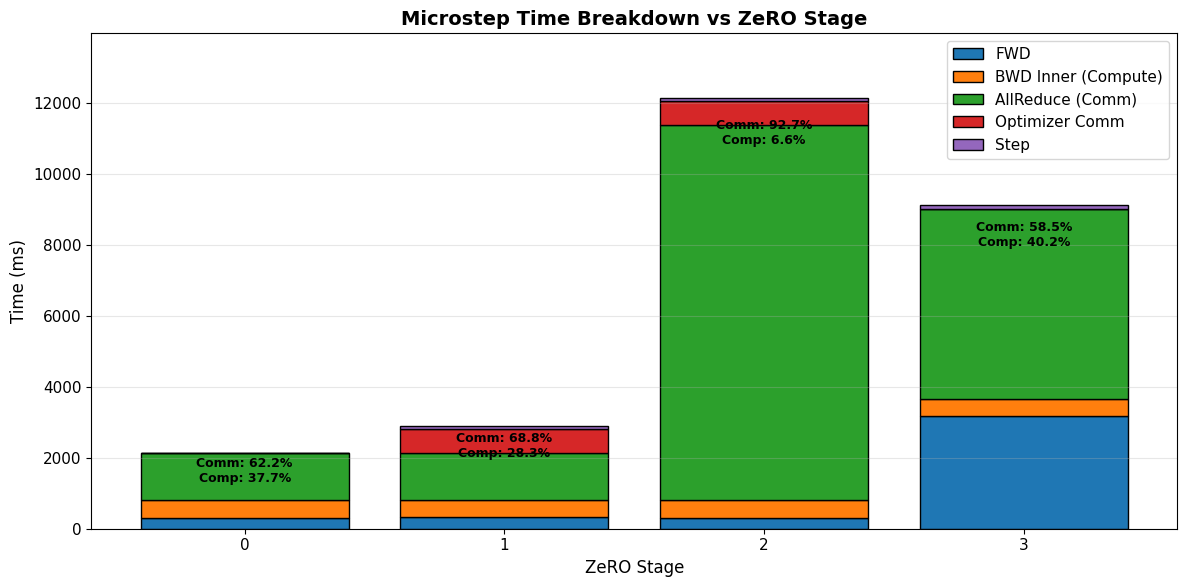

In [59]:
# ============================================================================
# TABLE 3: Communication Analysis (from Microstep Data)
# ============================================================================
print("\n" + "="*120)
print("TABLE 3: Communication Analysis by ZeRO Stage (from Microstep Data)")
print("="*120)

# Index(['fwd_microstep', 'bwd_microstep', 'bwd_inner_microstep',
#        'bwd_allreduce_microstep', 'step_microstep', 'real_compute_ms',
#        'real_comm_ms', 'total_microstep_time', 'total_effective_time',
#        'compute_pct', 'comm_pct', 'compute_comm_ratio', 'compute_efficiency',
#        'total_time_s', 'optimizer', 'stage', 'step'],
#       dtype='object')

micro_agg = {
    "fwd_microstep": "mean",
    "bwd_microstep": "mean",
    "bwd_inner_microstep": "mean",
    "bwd_allreduce_microstep": "mean",
    'step_microstep': "mean",
    "optimizer": "max"
}

micro_summary = df_micro_all.groupby("stage").agg(micro_agg).reset_index()

table3 = micro_summary[[
    "stage",
    "fwd_microstep",
    "bwd_microstep",
    "bwd_inner_microstep",
    "bwd_allreduce_microstep",
    "step_microstep",
    "optimizer"
]].copy()

table3.columns = [
    "ZeRO Stage",
    "FWD (ms)",
    "BWD (ms)",
    "BWD Inner (ms)",
    "AllReduce (ms)",
    "Step (ms)",
    "Optimizer Comm (ms)"
]




print(table3.round(4).to_string(index=False))

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# ----------------------------
# Data
# ----------------------------
stages = micro_summary["stage"].values
x = np.arange(len(stages))

fwd = micro_summary["fwd_microstep"].values
bwd_inner = micro_summary["bwd_inner_microstep"].values
allreduce = micro_summary["bwd_allreduce_microstep"].values
optimizer = micro_summary["optimizer"].values
step = micro_summary["step_microstep"].values

# ----------------------------
# Stacked bars
# ----------------------------
bars1 = plt.bar(x, fwd, label="FWD", edgecolor='black')
bars2 = plt.bar(x, bwd_inner, bottom=fwd, label="BWD Inner (Compute)", edgecolor='black')
bars3 = plt.bar(x, allreduce, bottom=fwd + bwd_inner, label="AllReduce (Comm)", edgecolor='black')
bars4 = plt.bar(x, optimizer, bottom=fwd + bwd_inner + allreduce, label="Optimizer Comm", edgecolor='black')
bars5 = plt.bar(x, step, bottom=fwd + bwd_inner + allreduce + optimizer, label="Step", edgecolor='black')

# ----------------------------
# Total height for annotations
# ----------------------------
total_height = fwd + bwd_inner + allreduce + optimizer + step

# Compute / Comm %
compute = fwd + bwd_inner
comm = allreduce + optimizer

compute_pct = (compute / total_height) * 100
comm_pct = (comm / total_height) * 100

# ----------------------------
# Annotations
# ----------------------------

ymax = total_height.max()
plt.ylim(0, ymax * 1.15)  # small headroom

for i, x_pos in enumerate(x):
    # place text slightly below top of stack
    y_pos = total_height[i] * 0.95

    plt.text(
        x_pos,
        y_pos,
        f'Comm: {comm_pct[i]:.1f}%\nComp: {compute_pct[i]:.1f}%',
        ha='center',
        va='top',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

# ----------------------------
# Labels & styling
# ----------------------------
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Time (ms)", fontsize=12)
plt.title("Microstep Time Breakdown vs ZeRO Stage", fontsize=14, fontweight='bold')
plt.xticks(x, stages)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("03_microstep_breakdown.png", dpi=200, bbox_inches='tight')
plt.show()


TABLE 5: Total Forward/Backward Time Breakdown
 ZeRO Stage  Iter Time (ms)   FWD (ms)   BWD (ms)  Step (ms)  FWD %  BWD %  Step %
          0      1025161.11  149573.59  874989.41     598.11  14.59  85.35    0.06
          1      1105350.14  151894.28  873536.65   40348.30  13.74  79.03    3.65
          2      5551088.49  146957.03 5323088.31   41460.85   2.65  95.89    0.75
          3      4386818.96 1529649.99 2799213.25   57955.72  34.87  63.81    1.32


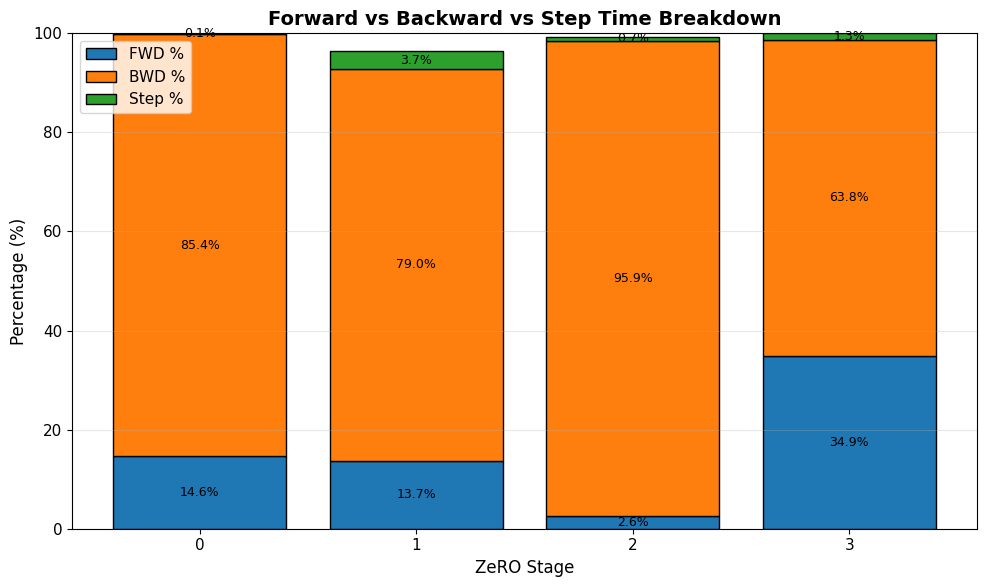

In [60]:
# ============================================================================
# TABLE 5: Forward/Backward Breakdown
# ============================================================================
# Index(['fwd_microstep', 'bwd_microstep', 'bwd_inner_microstep',
#        'bwd_allreduce_microstep', 'step_microstep', 'real_compute_ms',
#        'real_comm_ms', 'total_microstep_time', 'total_effective_time',
#        'compute_pct', 'comm_pct', 'compute_comm_ratio', 'compute_efficiency',
#        'total_time_s', 'optimizer', 'stage', 'step'],
#       dtype='object')

print("\n" + "="*120)
print("TABLE 5: Total Forward/Backward Time Breakdown")
print("="*120)

cols = ["stage", "total_microstep_time",'fwd_microstep', 'bwd_microstep', 'step_microstep']

micro_agg = {
    "fwd_microstep": "sum",
    "bwd_microstep": "sum",
    'step_microstep': "sum",
    "total_microstep_time": "sum"
}

micro_summary = df_micro_all.groupby("stage").agg(micro_agg).reset_index()
table5 = micro_summary[cols].copy()
table5["fwd_pct"] = (table5["fwd_microstep"] / table5["total_microstep_time"]) * 100 if 'fwd_microstep' in table5.columns else 0
table5["bwd_pct"] = (table5["bwd_microstep"] / table5["total_microstep_time"]) * 100 if 'bwd_microstep' in table5.columns else 0
table5["step_pct"] = (table5["step_microstep"] / table5["total_microstep_time"]) * 100 if 'step_microstep' in table5.columns else 0

table5.columns = ["ZeRO Stage", "Iter Time (ms)", "FWD (ms)", "BWD (ms)", "Step (ms)", "FWD %", "BWD %", "Step %"]
print(table5.round(2).to_string(index=False))



plt.figure(figsize=(10, 6))

stages = table5["ZeRO Stage"].values
x = np.arange(len(stages))

fwd_pct = table5["FWD %"].values
bwd_pct = table5["BWD %"].values
step_pct = table5["Step %"].values

# ----------------------------
# Stacked % bars
# ----------------------------
bars1 = plt.bar(x, fwd_pct, label="FWD %", edgecolor='black')
bars2 = plt.bar(x, bwd_pct, bottom=fwd_pct, label="BWD %", edgecolor='black')
bars3 = plt.bar(x, step_pct, bottom=fwd_pct + bwd_pct, label="Step %", edgecolor='black')

# ----------------------------
# Annotations inside bars
# ----------------------------
for i in range(len(x)):
    plt.text(x[i], fwd_pct[i]/2, f"{fwd_pct[i]:.1f}%", ha='center', va='center', fontsize=9)
    plt.text(x[i], fwd_pct[i] + bwd_pct[i]/2, f"{bwd_pct[i]:.1f}%", ha='center', va='center', fontsize=9)
    plt.text(x[i], fwd_pct[i] + bwd_pct[i] + step_pct[i]/2, f"{step_pct[i]:.1f}%", ha='center', va='center', fontsize=9)

# ----------------------------
# Labels
# ----------------------------
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Forward vs Backward vs Step Time Breakdown", fontsize=14, fontweight='bold')
plt.xticks(x, stages)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("05_fwd_bwd_pct_breakdown.png", dpi=200, bbox_inches='tight')
plt.show()


TABLE 6: Microstep Component Breakdown
 Stage  Total (ms)  Compute Eff (%)  FWD (ms)  FWD %  BWD (ms)  BWD %  BWD Inner (ms)  BWD Inner %  AllReduce (ms)  AllReduce %  Optimizer (ms)  Optimizer %  Step (ms)  Step %  Compute (ms)  Compute %  Comm (ms)  Comm %
     0     2135.75            88.33    311.61  14.59   1822.89  85.35          493.57        23.11         1329.00        62.23            0.00         0.00       1.25    0.06        805.18      37.70    1329.00   62.23
     1     2302.81            88.24    316.45  13.74   1819.87  79.03          499.04        21.67         1320.43        57.34           82.44         3.58      84.06    3.65        815.48      35.41    1402.87   60.92
     2    11564.77             6.94    306.16   2.65  11089.77  95.89          495.34         4.28        10594.01        91.61           82.46         0.71      86.38    0.75        801.50       6.93   10676.47   92.32
     3     9139.21            40.17   3186.77  34.87   5831.69  63.81          4

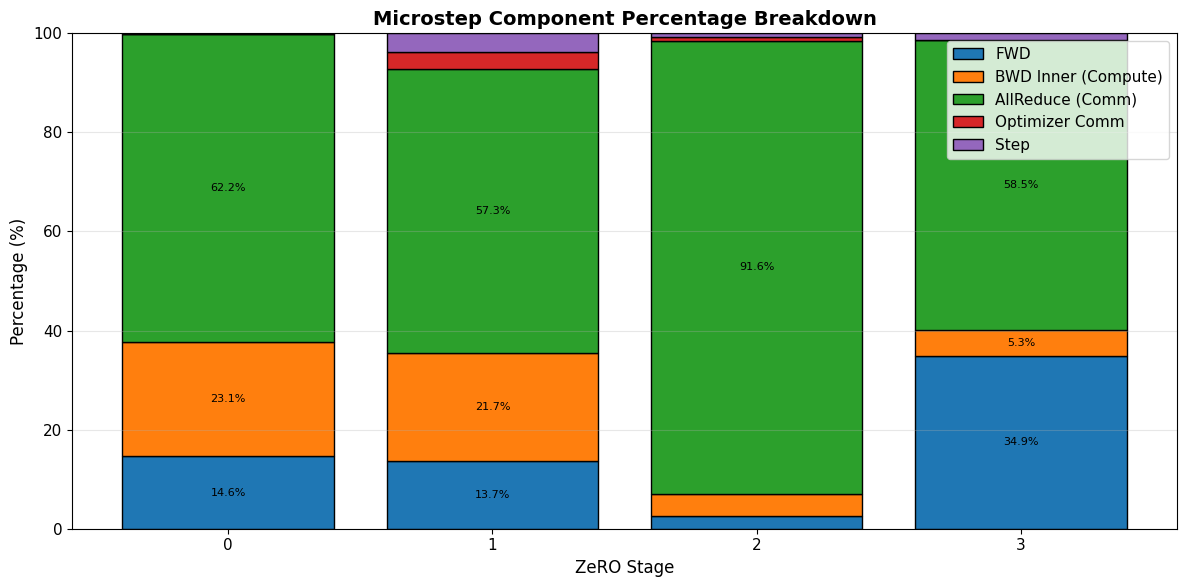

In [61]:
# ============================================================================
# TABLE 6: Microstep Component Breakdown
# ============================================================================
micro_summary = df_micro_all.groupby("stage").mean().reset_index()
print("\n" + "="*120)
print("TABLE 6: Microstep Component Breakdown")
print("="*120)


table6 = micro_summary.copy()

# ----------------------------
# Percent breakdowns
# ----------------------------
table6["fwd_pct"] = table6["fwd_microstep"] / table6["total_microstep_time"] * 100
table6["bwd_pct"] = table6["bwd_microstep"] / table6["total_microstep_time"] * 100
table6["bwd_inner_pct"] = table6["bwd_inner_microstep"] / table6["total_microstep_time"] * 100
table6["allreduce_pct"] = table6["bwd_allreduce_microstep"] / table6["total_microstep_time"] * 100
table6["step_pct"] = table6["step_microstep"] / table6["total_microstep_time"] * 100
table6["optimizer_pct"] = table6["optimizer"] / table6["total_microstep_time"] * 100

table6["compute_pct"] = table6["real_compute_ms"] / table6["total_microstep_time"] * 100
table6["comm_pct"] = table6["real_comm_ms"] / table6["total_microstep_time"] * 100

# ----------------------------
# Select & rename columns
# ----------------------------
table6 = table6[[
    "stage",
    "total_microstep_time",
    "compute_efficiency",

    "fwd_microstep", "fwd_pct",
    "bwd_microstep", "bwd_pct",
    "bwd_inner_microstep", "bwd_inner_pct",
    "bwd_allreduce_microstep", "allreduce_pct",
    "optimizer", "optimizer_pct",
    "step_microstep", "step_pct",

    "real_compute_ms", "compute_pct",
    "real_comm_ms", "comm_pct"
]]

table6.columns = [
    "Stage",
    "Total (ms)",
    "Compute Eff (%)",

    "FWD (ms)", "FWD %",
    "BWD (ms)", "BWD %",
    "BWD Inner (ms)", "BWD Inner %",
    "AllReduce (ms)", "AllReduce %",
    "Optimizer (ms)", "Optimizer %",
    "Step (ms)", "Step %",

    "Compute (ms)", "Compute %",
    "Comm (ms)", "Comm %"
]

print(table6.round(2).to_string(index=False))


plt.figure(figsize=(12, 6))

stages = table6["Stage"].values
x = np.arange(len(stages))

fwd = table6["FWD %"].values
bwd_inner = table6["BWD Inner %"].values
allreduce = table6["AllReduce %"].values
optimizer = table6["Optimizer %"].values
step = table6["Step %"].values

# ----------------------------
# Stacked % bars
# ----------------------------
bars1 = plt.bar(x, fwd, label="FWD", edgecolor='black')
bars2 = plt.bar(x, bwd_inner, bottom=fwd, label="BWD Inner (Compute)", edgecolor='black')
bars3 = plt.bar(x, allreduce, bottom=fwd + bwd_inner, label="AllReduce (Comm)", edgecolor='black')
bars4 = plt.bar(x, optimizer, bottom=fwd + bwd_inner + allreduce, label="Optimizer Comm", edgecolor='black')
bars5 = plt.bar(x, step, bottom=fwd + bwd_inner + allreduce + optimizer, label="Step", edgecolor='black')

# ----------------------------
# Annotation (only major parts to avoid clutter)
# ----------------------------
for i in range(len(x)):
    total = 100

    if fwd[i] > 5:
        plt.text(x[i], fwd[i]/2, f"{fwd[i]:.1f}%", ha='center', va='center', fontsize=8)

    if bwd_inner[i] > 5:
        plt.text(x[i], fwd[i] + bwd_inner[i]/2, f"{bwd_inner[i]:.1f}%", ha='center', va='center', fontsize=8)

    if allreduce[i] > 5:
        plt.text(x[i], fwd[i] + bwd_inner[i] + allreduce[i]/2, f"{allreduce[i]:.1f}%", ha='center', va='center', fontsize=8)

# ----------------------------
# Labels
# ----------------------------
plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.title("Microstep Component Percentage Breakdown", fontsize=14, fontweight='bold')
plt.xticks(x, stages)
plt.ylim(0, 100)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("06_microstep_component_pct.png", dpi=200, bbox_inches='tight')
plt.show()

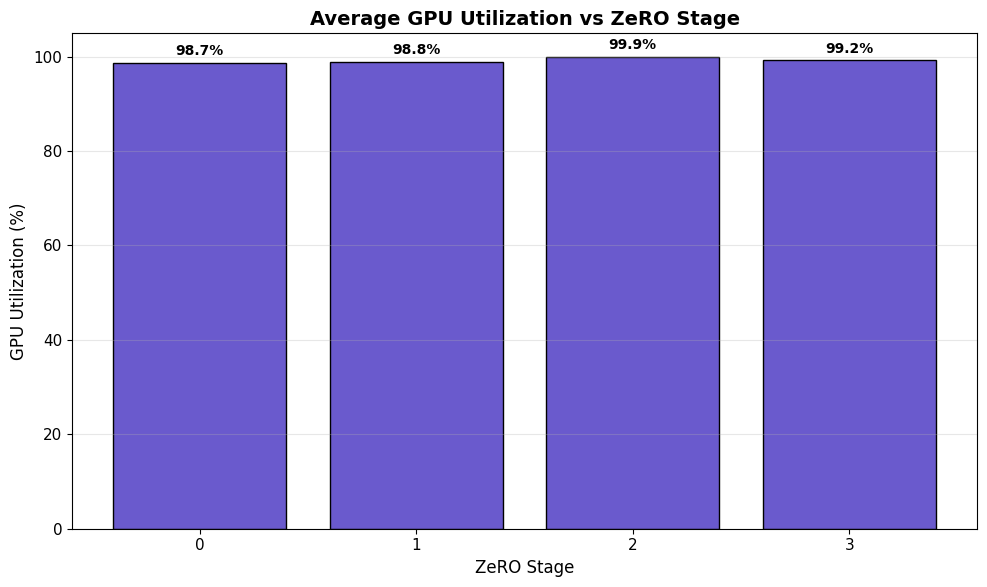

In [62]:
# Plot 4: GPU Utilization Bar Chart
if 'gpu_util' in summary.columns:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary["stage"], summary["gpu_util"], color='slateblue', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("GPU Utilization (%)", fontsize=12)
    plt.title("Average GPU Utilization vs ZeRO Stage", fontsize=14, fontweight='bold')
    plt.xticks(summary["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, summary["gpu_util"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('04_gpu_util_bar.png', dpi=150, bbox_inches='tight')
    plt.show()


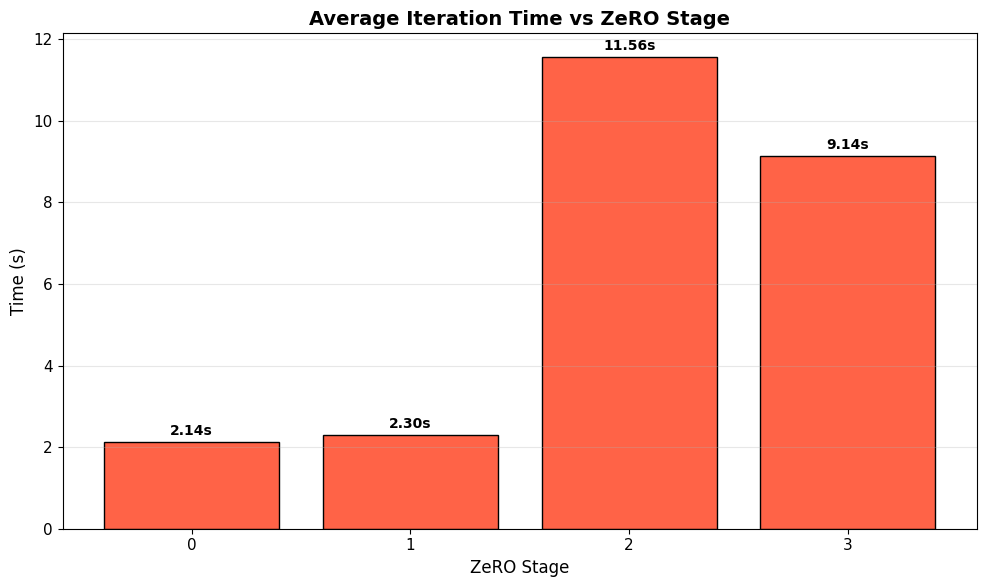

In [63]:

# Plot 5: Iteration Time Bar Chart
if 'avg_microstep_time_s' in summary.columns:
    plt.figure(figsize=(10, 6))
    bars = plt.bar(summary["stage"], summary["avg_microstep_time_s"], color='tomato', edgecolor='black')
    plt.xlabel("ZeRO Stage", fontsize=12)
    plt.ylabel("Time (s)", fontsize=12)
    plt.title("Average Iteration Time vs ZeRO Stage", fontsize=14, fontweight='bold')
    plt.xticks(summary["stage"])
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, summary["avg_microstep_time_s"]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}s', 
                 ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('05_iteration_time_bar.png', dpi=150, bbox_inches='tight')
    plt.show()


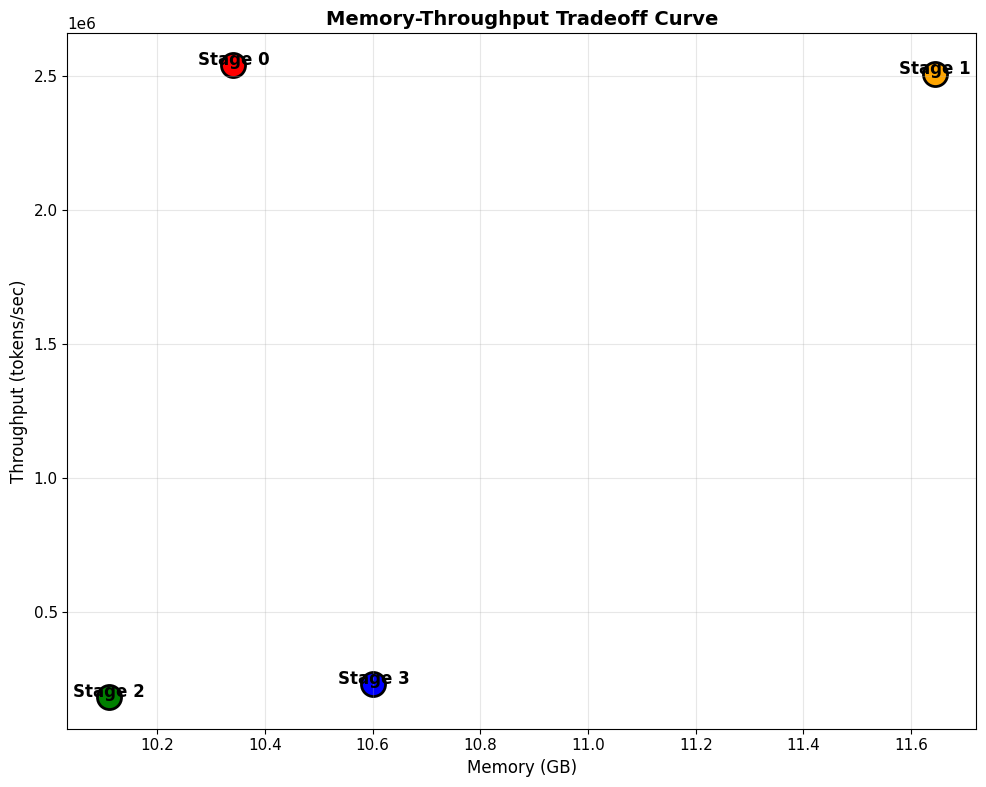

In [64]:
# Plot 6: Memory vs Throughput Tradeoff
if 'peak_gb' in summary.columns and 'throughput_tps' in summary.columns:
    plt.figure(figsize=(10, 8))
    colors = ['red', 'orange', 'green', 'blue']
    for i, row in summary.iterrows():
        plt.scatter(row["peak_gb"], row["throughput_tps"], s=300, 
                   c=[colors[i]], edgecolor='black', linewidth=2)
        plt.text(row["peak_gb"], row["throughput_tps"] + 15, f"Stage {int(row['stage'])}", 
                 ha='center', fontweight='bold', fontsize=12)
    
    plt.xlabel("Memory (GB)", fontsize=12)
    plt.ylabel("Throughput (tokens/sec)", fontsize=12)
    plt.title("Memory-Throughput Tradeoff Curve", fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('06_memory_throughput_tradeoff.png', dpi=150, bbox_inches='tight')
    plt.show()

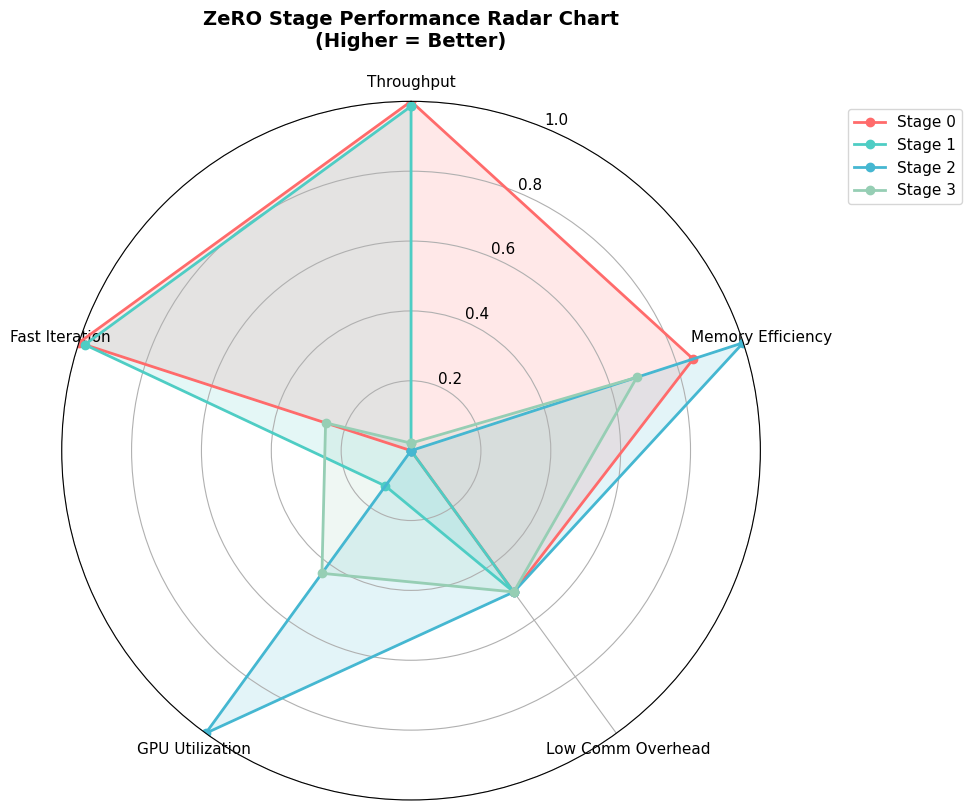

,stage,total_microstep_time,throughput_tps,peak_gb,alloc_gb,reserved_gb,temp_c,gpu_util,compute_ms,comm_ms,...,compute_pct,compute_efficiency,compute_comm_ratio,total_training_time_s,avg_microstep_time_s,comm_pct_y,throughput_tps_norm,peak_gb_norm,gpu_util_norm,avg_microstep_time_s_norm
0,0,807.741333,2.539736e+06,10.341675,1.676796,9.621549,67.191667,98.658333,96884.90,2.55,...,99.992401,99.954566,39632.536886,1025.16111,2.135752,11.618002,1.000000,0.849014,0.000000,1.000000
1,1,817.069333,2.506467e+06,11.644409,1.989229,10.849089,69.150000,98.816667,97995.31,2.59,...,99.992246,99.945946,39261.061365,1105.35014,2.302813,11.049401,0.985879,0.000000,0.124939,0.982282
2,2,11408.183333,1.837608e+05,10.110000,1.192059,9.351510,59.756198,99.925620,97659.40,1271268.52,...,7.123297,7.123043,0.076827,5551.08849,11.564768,92.384442,0.000000,1.000000,1.000000,0.000000
3,3,9086.528833,2.344492e+05,10.601440,1.521060,9.882575,55.150000,99.208333,448457.16,641843.96,...,41.072463,41.069576,0.698659,4386.81896,9.139206,58.660233,0.021515,0.679720,0.433998,0.257244


In [66]:
micro_comm_summary = df_micro_all.groupby("stage").mean().reset_index()[["stage", "comm_pct"]]

# Plot 8: Radar Chart
if all(c in summary.columns for c in ['throughput_tps', 'peak_gb', 'gpu_util', 'avg_microstep_time_s']):
    metrics_for_radar = ['throughput_tps', 'peak_gb', 'gpu_util', 'avg_microstep_time_s']
    summary_norm = summary.copy()
    summary_norm = summary_norm.merge(micro_comm_summary, on="stage", how="left")
    
    for metric in metrics_for_radar:
        if metric in ['throughput_tps', 'gpu_util']:
            summary_norm[f'{metric}_norm'] = (summary_norm[metric] - summary_norm[metric].min()) / (summary_norm[metric].max() - summary_norm[metric].min())
        else:
            summary_norm[f'{metric}_norm'] = 1 - (summary_norm[metric] - summary_norm[metric].min()) / (summary_norm[metric].max() - summary_norm[metric].min())
    
    if 'comm_pct' in summary_norm.columns:
        summary_norm['comm_pct_norm'] = 1 - (summary_norm['comm_pct'] - summary_norm['comm_pct'].min()) / (summary_norm['comm_pct'].max() - summary_norm['comm_pct'].min())
    
    categories = ['Throughput', 'Memory Efficiency', 'Low Comm Overhead', 'GPU Utilization', 'Fast Iteration']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, projection='polar')
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    for idx, stage in enumerate(summary_norm['stage']):
        values = [
            summary_norm.loc[idx, 'throughput_tps_norm'],
            summary_norm.loc[idx, 'peak_gb_norm'],
            summary_norm.loc[idx, 'comm_pct_norm'] if 'comm_pct_norm' in summary_norm.columns else 0.5,
            summary_norm.loc[idx, 'gpu_util_norm'],
            summary_norm.loc[idx, 'avg_microstep_time_s_norm']
        ]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=f'Stage {int(stage)}', color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_ylim(0, 1)
    ax.set_title('ZeRO Stage Performance Radar Chart\n(Higher = Better)', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    plt.tight_layout()
    plt.savefig('08_radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

summary_norm

In [30]:
# ============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("PERFORMANCE SUMMARY TABLE")
print("="*80)
print(summary.round(2).to_string(index=False))

print("\n" + "="*80)
print("COMMUNICATION PERCENTAGE (FROM MICROSTEP DATA)")
print("="*80)
print(micro_comm_summary.round(2).to_string(index=False))

print("\n" + "="*80)
print("TRADEOFF ANALYSIS")
print("="*80)

for _, row in summary.iterrows():
    stage = int(row['stage'])
    print(f"\nZeRO Stage {stage}:")
    if 'throughput_tps' in row:
        print(f"  • Throughput: {row['throughput_tps']:.1f} tokens/sec")
    if 'peak_gb' in row:
        print(f"  • Memory: {row['peak_gb']:.1f} GB")
    comm_val = micro_comm_summary[micro_comm_summary['stage'] == stage]['comm_pct'].values[0] if not micro_comm_summary.empty else 0
    print(f"  • Communication Overhead (Microstep): {comm_val:.1f}%")
    if 'gpu_util' in row:
        print(f"  • GPU Utilization: {row['gpu_util']:.1f}%")
    if 'iteration_time_ms' in row:
        print(f"  • Iteration Time: {row['iteration_time_ms']:.0f} ms")

print("\n" + "="*80)
print("RECOMMENDATIONS")
print("="*80)

if 'throughput_tps' in summary.columns and not summary['throughput_tps'].isna().all():
    best_throughput = summary.loc[summary['throughput_tps'].idxmax(), 'stage']
    print(f"\n• Best for Throughput: ZeRO Stage {int(best_throughput)}")

if 'peak_gb' in summary.columns and not summary['peak_gb'].isna().all():
    best_memory = summary.loc[summary['peak_gb'].idxmin(), 'stage']
    print(f"• Best for Memory: ZeRO Stage {int(best_memory)}")
    
    if 'throughput_tps' in summary.columns:
        throughput_norm = summary['throughput_tps'] / summary['throughput_tps'].max()
        memory_norm = summary['peak_gb'] / summary['peak_gb'].max()
        balance_score = throughput_norm - memory_norm
        best_balance = summary.loc[balance_score.idxmax(), 'stage']
        print(f"• Best Tradeoff (Memory+Throughput): ZeRO Stage {int(best_balance)}")

# • ZeRO Stage 1 provides the best balance of throughput and efficiency
# • ZeRO Stage 0 is optimal when memory is not a constraint
# • ZeRO Stage 2 shows severe communication bottlenecks in this setup and is not recommended
# • ZeRO Stage 3 enables memory scaling but at significant performance cost

# • Final Recommendation:
#     → Use Stage 1 for most workloads
#     → Use Stage 3 only when memory is a bottleneck


PERFORMANCE SUMMARY TABLE
 stage  total_microstep_time  throughput_tps  peak_gb  alloc_gb  reserved_gb  temp_c  gpu_util  compute_ms    comm_ms  comm_pct    fwd_ms     bwd_ms  step_ms  compute_pct  compute_efficiency  compute_comm_ratio  total_training_time_s  avg_microstep_time_s
     0                807.74      2539736.39    10.34      1.68         9.62   67.19     98.66    96884.90       2.55      0.00  37636.72   59287.41   275.82        99.99               99.95            39632.54                1025.16                  2.14
     1                817.07      2506467.00    11.64      1.99        10.85   69.15     98.82    97995.31       2.59      0.00  38108.47   59934.83   249.14        99.99               99.95            39261.06                1105.31                  2.30
     2              11408.18       183760.75    10.11      1.19         9.35   59.76     99.93    97659.40 1271268.52     92.88  37180.15 1331796.54   235.66         7.12                7.12               


TABLE 8: Performance Improvement/Regression vs Stage 0 (Baseline)
 ZeRO Stage  Throughput Change (%)  Memory Reduction (peak) (%)  Memory Reduction (alloc) (%)  Comm Increase (pp)  Compute Eff Change (pp)  GPU Util Change (pp)
          1                  -1.31                       -10.62                        -15.71                0.00                    -0.01                  0.16
          2                 -92.76                         2.52                         40.66               92.87                   -92.83                  1.27
          3                 -90.77                        -2.26                         10.24               58.92                   -58.88                  0.55


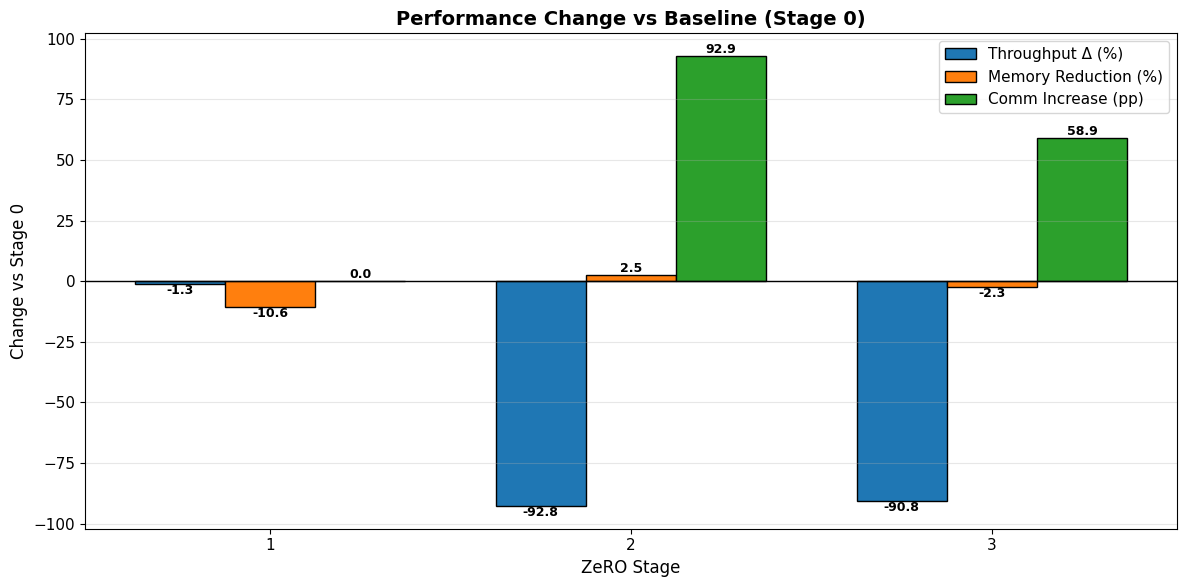

In [293]:
import pandas as pd
import numpy as np

print("\n" + "="*120)
print("TABLE 8: Performance Improvement/Regression vs Stage 0 (Baseline)")
print("="*120)

# ----------------------------
# Build summary from df_all
# ----------------------------
summary = df_all.groupby("stage").agg({
    "throughput_tps": "mean",
    "peak_gb": "mean",
    "alloc_gb": "mean",
    "comm_pct": "mean",
    "gpu_util": "mean",
    "compute_efficiency": "mean"   # optional but useful
}).reset_index()

# ----------------------------
# Ensure Stage 0 exists
# ----------------------------
if 0 not in summary["stage"].values:
    print("❌ Stage 0 not found. Cannot compute comparison.")
else:
    baseline = summary[summary["stage"] == 0].iloc[0]

    def safe_pct_change(new, base):
        if base == 0 or np.isnan(base):
            return np.nan
        return ((new - base) / base) * 100

    def safe_diff(new, base):
        if np.isnan(new) or np.isnan(base):
            return np.nan
        return new - base

    comparison_rows = []

    for _, row in summary.iterrows():
        stage = int(row["stage"])
        if stage == 0:
            continue

        throughput_change = safe_pct_change(
            row["throughput_tps"], baseline["throughput_tps"]
        )

        memory_reduction = safe_pct_change(
            baseline["peak_gb"], row["peak_gb"]
        )
        memory_reduction2 = safe_pct_change(
            baseline["alloc_gb"], row["alloc_gb"]
        )

        comm_increase = safe_diff(
            row["comm_pct"], baseline["comm_pct"]
        )

        gpu_util_change = safe_diff(
            row["gpu_util"], baseline["gpu_util"]
        )

        compute_eff_change = safe_diff(
            row.get("compute_efficiency", np.nan),
            baseline.get("compute_efficiency", np.nan)
        )

        comparison_rows.append({
            "ZeRO Stage": stage,
            "Throughput Change (%)": round(throughput_change, 2) if not np.isnan(throughput_change) else "N/A",
            "Memory Reduction (peak) (%)": round(memory_reduction, 2) if not np.isnan(memory_reduction) else "N/A",
            "Memory Reduction (alloc) (%)": round(memory_reduction2, 2) if not np.isnan(memory_reduction2) else "N/A",
            "Comm Increase (pp)": round(comm_increase, 2) if not np.isnan(comm_increase) else "N/A",
            "Compute Eff Change (pp)": round(compute_eff_change, 2) if not np.isnan(compute_eff_change) else "N/A",
            "GPU Util Change (pp)": round(gpu_util_change, 2) if not np.isnan(gpu_util_change) else "N/A"
        })

    table8 = pd.DataFrame(comparison_rows)

    print(table8.to_string(index=False))



    import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Prepare data
# ----------------------------
stages = table8["ZeRO Stage"].values
x = np.arange(len(stages))
width = 0.25

throughput = table8["Throughput Change (%)"].replace("N/A", 0).astype(float)
mem_peak = table8["Memory Reduction (peak) (%)"].replace("N/A", 0).astype(float)
comm = table8["Comm Increase (pp)"].replace("N/A", 0).astype(float)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(12, 6))

bars1 = plt.bar(x - width, throughput, width, label="Throughput Δ (%)", edgecolor='black')
bars2 = plt.bar(x, mem_peak, width, label="Memory Reduction (%)", edgecolor='black')
bars3 = plt.bar(x + width, comm, width, label="Comm Increase (pp)", edgecolor='black')

# ----------------------------
# Annotations
# ----------------------------
def annotate(bars):
    for bar in bars:
        val = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val,
            f'{val:.1f}',
            ha='center',
            va='bottom' if val >= 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

annotate(bars1)
annotate(bars2)
annotate(bars3)

# ----------------------------
# Styling
# ----------------------------
plt.axhline(0, color='black', linewidth=1)  # baseline line

plt.xlabel("ZeRO Stage", fontsize=12)
plt.ylabel("Change vs Stage 0", fontsize=12)
plt.title("Performance Change vs Baseline (Stage 0)", fontsize=14, fontweight='bold')
plt.xticks(x, stages)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("08_performance_change.png", dpi=200, bbox_inches='tight')
plt.show()

✓ Loaded 16 perplexity entries for Stage 0
✓ Loaded 16 perplexity entries for Stage 1
✓ Loaded 17 perplexity entries for Stage 2
✓ Loaded 16 perplexity entries for Stage 3

Total loaded: 65 entries
   stage  step  perplexity      checkpoint
0      0   128  20005.9102  global_step128
1      0   160  17503.9651  global_step160
2      0   192  15286.0029  global_step192
3      0   224  13181.5617  global_step224
4      0   256  11397.6734  global_step256


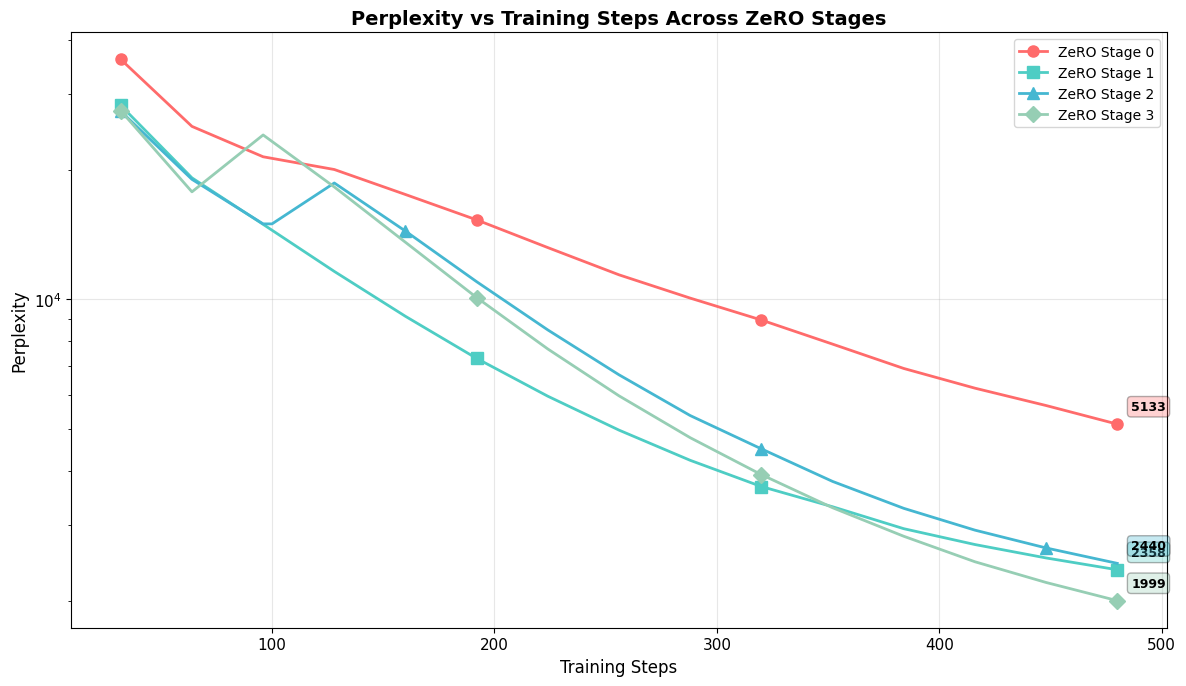

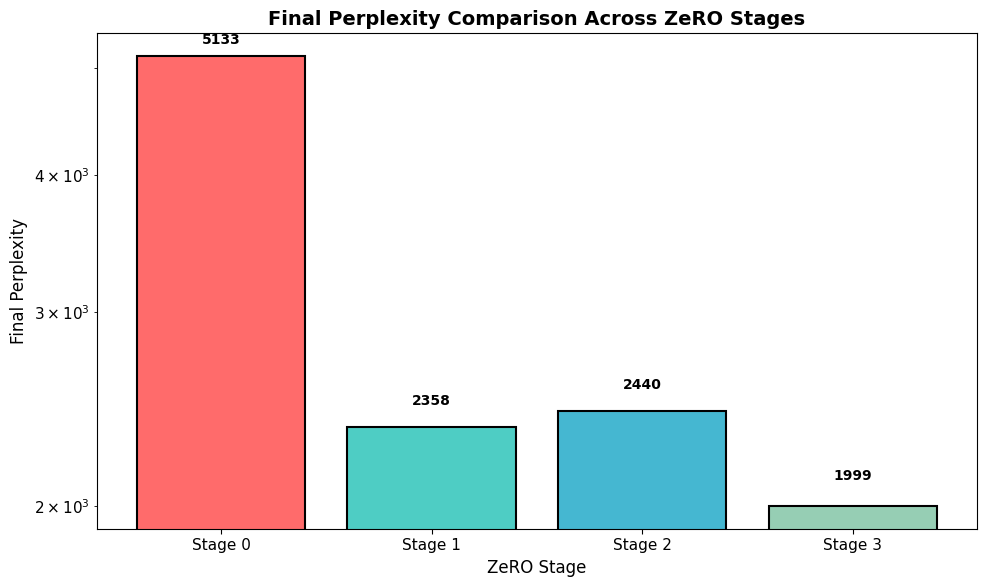

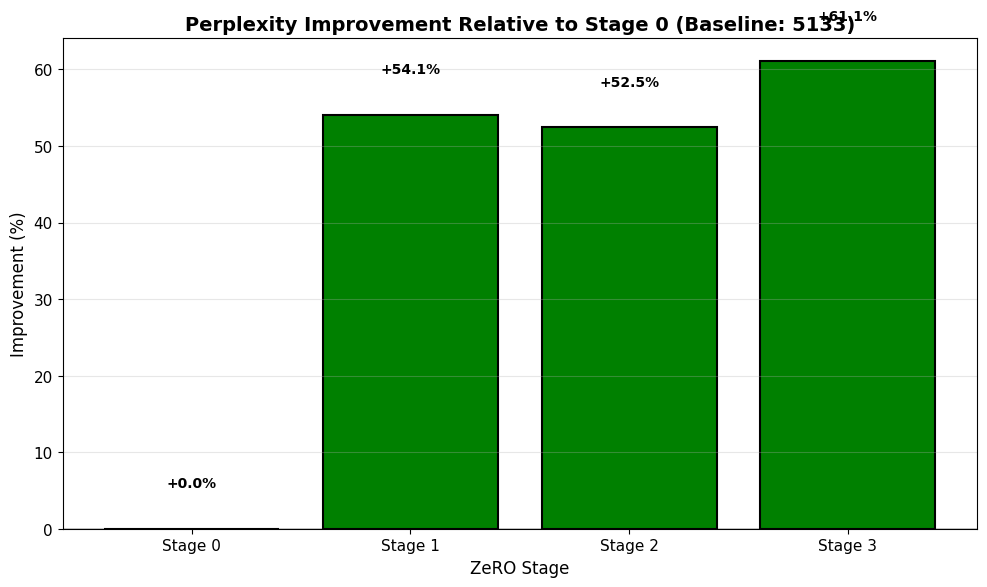

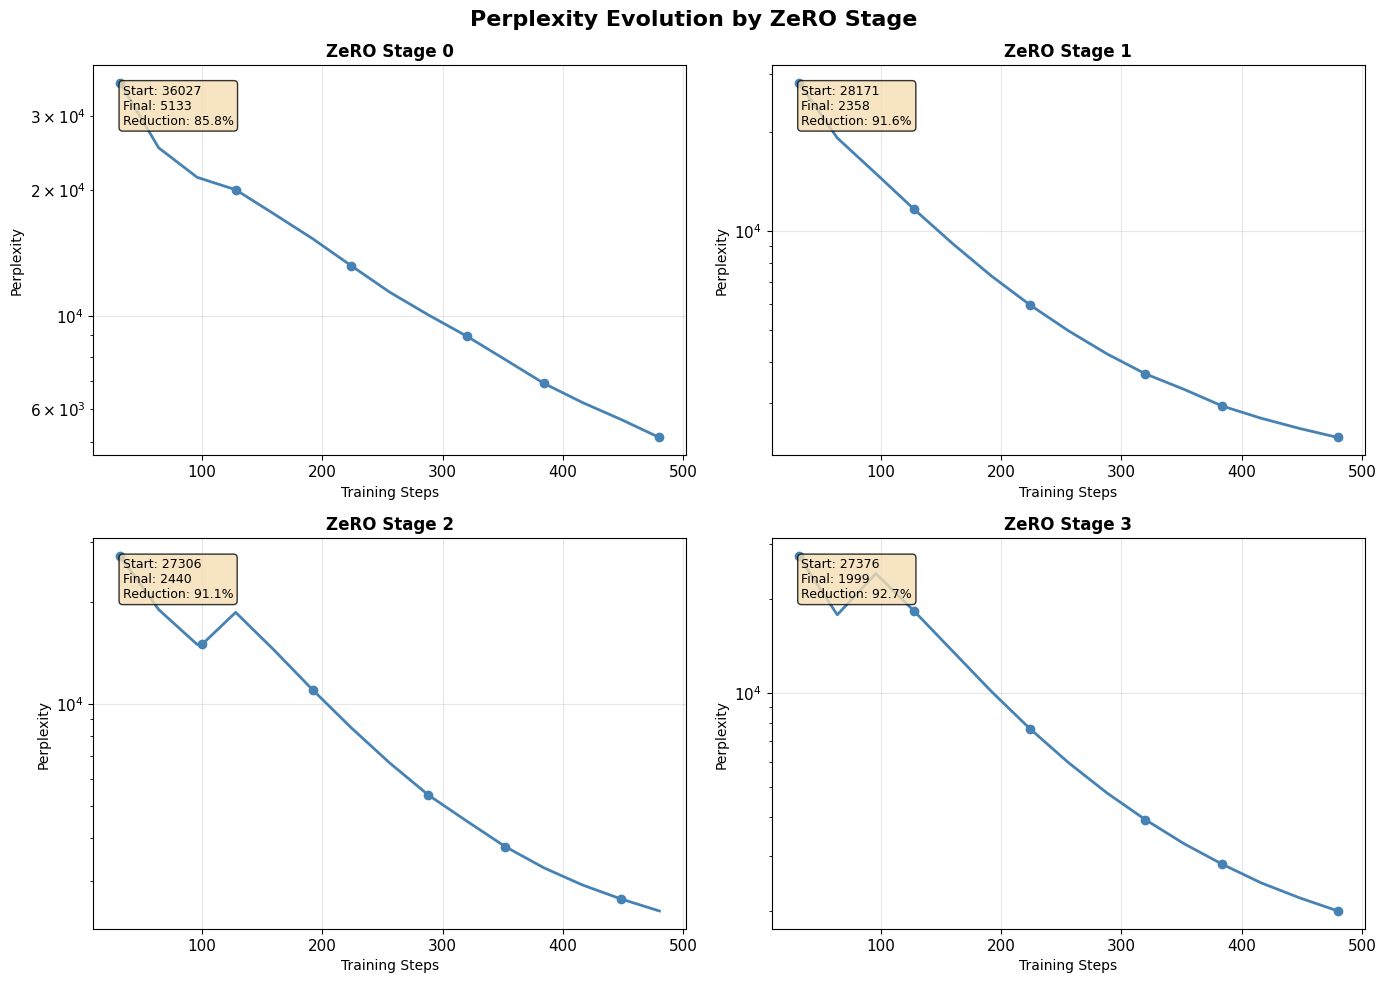

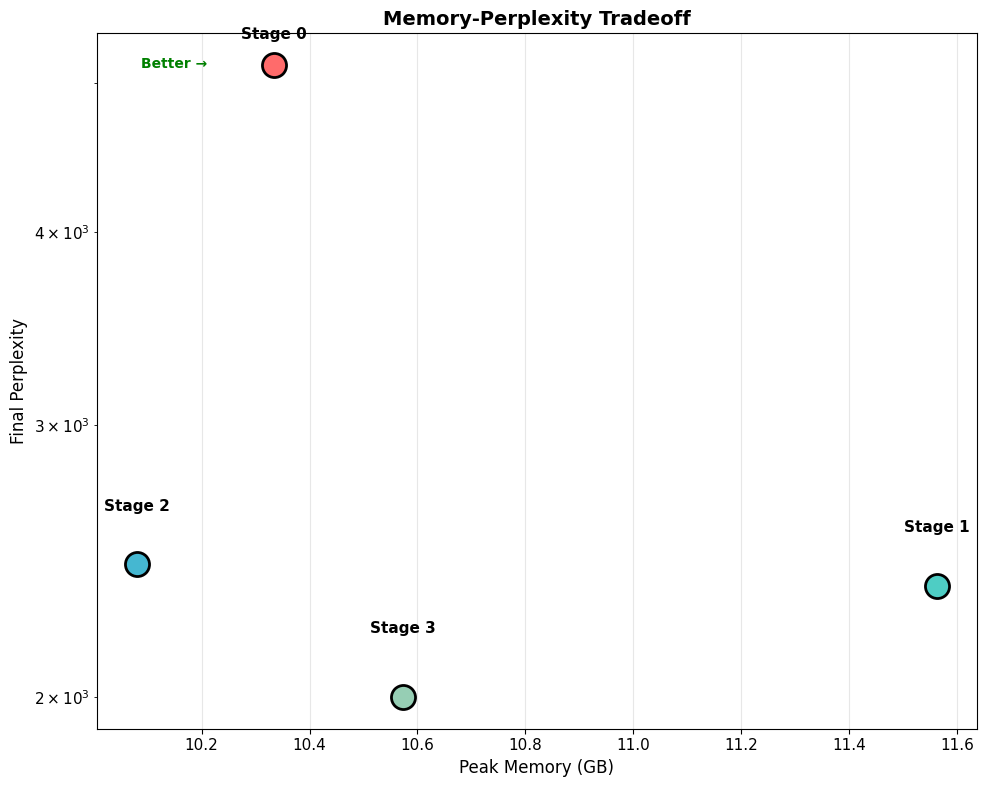


PERPLEXITY RESULTS SUMMARY
 Stage Initial Perplexity Final Perplexity Improvement  Checkpoints
     0              36027             5133       85.8%           16
     1              28171             2358       91.6%           16
     2              27306             2440       91.1%           17
     3              27376             1999       92.7%           16

BEST PERFORMING CONFIGURATION

Best Final Perplexity: ZeRO Stage 3
  Final Perplexity: 1999
  Improvement from start: 92.7%

Best Improvement Rate: ZeRO Stage 3
  Improvement: 92.7%
  Final Perplexity: 1999


In [102]:
# ============================================================================
# LOAD PERPLEXITY RESULTS FROM ALL STAGES
# ============================================================================

def load_perplexity_results(stage_paths):
    """
    Load perplexity results from JSON files for different ZeRO stages.
    
    Args:
        stage_paths: dict {stage_id: file_path}
    
    Returns:
        DataFrame with columns: stage, step, perplexity
    """
    all_data = []
    
    for stage_id, file_path in stage_paths.items():
        if Path(file_path).exists():
            with open(file_path, 'r') as f:
                data = json.load(f)
            
            for item in data:
                # Extract step number from checkpoint name (e.g., "global_step128")
                step = int(item['checkpoint'].split('_')[-1].replace("step",''))
                
                all_data.append({
                    'stage': stage_id,
                    'step': step,
                    'perplexity': item['perplexity'],
                    'checkpoint': item['checkpoint']
                })
            
            print(f"✓ Loaded {len(data)} perplexity entries for Stage {stage_id}")
        else:
            print(f"✗ File not found: {file_path}")
    
    df = pd.DataFrame(all_data)
    return df

# Define file paths
perplexity_files = {
    0: "../outputs/stage_0/perplexity_results.json",
    1: "../outputs/stage_1/perplexity_results.json",
    2: "../outputs/stage_2/perplexity_results.json",
    3: "../outputs/stage_3/perplexity_results.json"
}

# Load data
df_perplexity = load_perplexity_results(perplexity_files)

print(f"\nTotal loaded: {len(df_perplexity)} entries")
print(df_perplexity.head())

# ============================================================================
# PLOT 1: PERPLEXITY OVER TRAINING STEPS (LINE PLOT)
# ============================================================================
plt.figure(figsize=(12, 7))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
markers = ['o', 's', '^', 'D']

for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    plt.plot(stage_data['step'], stage_data['perplexity'], 
             marker=markers[idx], markersize=8, linewidth=2,
             label=f'ZeRO Stage {stage}', color=colors[idx], markevery=5)

plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Perplexity', fontsize=12)
plt.title('Perplexity vs Training Steps Across ZeRO Stages', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Perplexity typically improves exponentially, log scale helps visualization

# Add annotations for best perplexity at final step
for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        final_step = stage_data['step'].iloc[-1]
        final_ppl = stage_data['perplexity'].iloc[-1]
        plt.annotate(f'{final_ppl:.0f}', 
                    xy=(final_step, final_ppl),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx], alpha=0.3))

plt.tight_layout()
plt.savefig('perplexity_over_steps.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 2: PERPLEXITY BAR CHART (FINAL CHECKPOINT COMPARISON)
# ============================================================================
plt.figure(figsize=(10, 6))

# Get final perplexity for each stage
final_ppl = []
stages = []
for stage in sorted(df_perplexity['stage'].unique()):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        final_ppl.append(stage_data['perplexity'].iloc[-1])
        stages.append(stage)

bars = plt.bar([f'Stage {s}' for s in stages], final_ppl, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(stages)],
               edgecolor='black', linewidth=1.5)

plt.xlabel('ZeRO Stage', fontsize=12)
plt.ylabel('Final Perplexity', fontsize=12)
plt.title('Final Perplexity Comparison Across ZeRO Stages', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, final_ppl):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('final_perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 3: PERPLEXITY IMPROVEMENT RELATIVE TO STAGE 0
# ============================================================================
plt.figure(figsize=(10, 6))

# Get baseline (Stage 0 final perplexity)
stage0_data = df_perplexity[df_perplexity['stage'] == 0].sort_values('step')
if not stage0_data.empty:
    baseline_ppl = stage0_data['perplexity'].iloc[-1]
    
    improvements = []
    stages = []
    for stage in sorted(df_perplexity['stage'].unique()):
        stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
        if not stage_data.empty:
            final_ppl = stage_data['perplexity'].iloc[-1]
            improvement = (baseline_ppl - final_ppl) / baseline_ppl * 100
            improvements.append(improvement)
            stages.append(stage)
    
    colors_bar = ['red' if imp < 0 else 'green' for imp in improvements]
    bars = plt.bar([f'Stage {s}' for s in stages], improvements, 
                   color=colors_bar, edgecolor='black', linewidth=1.5)
    
    plt.xlabel('ZeRO Stage', fontsize=12)
    plt.ylabel('Improvement (%)', fontsize=12)
    plt.title(f'Perplexity Improvement Relative to Stage 0 (Baseline: {baseline_ppl:.0f})', 
              fontsize=14, fontweight='bold')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, imp in zip(bars, improvements):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if imp >= 0 else -15), 
                 f'{imp:+.1f}%', ha='center', va='bottom' if imp >= 0 else 'top', 
                 fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('perplexity_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# PLOT 4: SUBPLOT GRID WITH ALL STAGES
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perplexity Evolution by ZeRO Stage', fontsize=16, fontweight='bold')

for idx, stage in enumerate(sorted(df_perplexity['stage'].unique())):
    ax = axes[idx // 2, idx % 2]
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    
    ax.plot(stage_data['step'], stage_data['perplexity'], 
            marker='o', markersize=6, linewidth=2, color='steelblue', markevery=3)
    ax.set_xlabel('Training Steps', fontsize=10)
    ax.set_ylabel('Perplexity', fontsize=10)
    ax.set_title(f'ZeRO Stage {stage}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # Add annotations for key points
    first_ppl = stage_data['perplexity'].iloc[0]
    final_ppl = stage_data['perplexity'].iloc[-1]
    reduction = (first_ppl - final_ppl) / first_ppl * 100
    
    ax.text(0.05, 0.95, f'Start: {first_ppl:.0f}\nFinal: {final_ppl:.0f}\nReduction: {reduction:.1f}%',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)

plt.tight_layout()
plt.savefig('perplexity_subplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# PLOT 5: PERPLEXITY vs GPU MEMORY (Tradeoff Analysis)
# ============================================================================
# Merge with memory data from your training metrics
# If you have memory data from training, you can create this plot

# Example: Assuming you have a summary DataFrame with memory usage
# If not, you can skip this plot or add dummy data

try:
    # If you have df_all from previous analysis
    if 'df_all' in globals():
        memory_by_stage = df_all.groupby('stage')['peak_gb'].mean().reset_index()
        perplexity_by_stage = df_perplexity.groupby('stage').agg({
            'perplexity': 'last'
        }).reset_index()
        
        merged = pd.merge(memory_by_stage, perplexity_by_stage, on='stage')
        
        plt.figure(figsize=(10, 8))
        for _, row in merged.iterrows():
            plt.scatter(row['peak_gb'], row['perplexity'], s=300, 
                       c=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][int(row['stage'])],
                       edgecolor='black', linewidth=2)
            plt.text(row['peak_gb'], row['perplexity'] + 200, f"Stage {int(row['stage'])}", 
                    ha='center', fontweight='bold', fontsize=11)
        
        plt.xlabel('Peak Memory (GB)', fontsize=12)
        plt.ylabel('Final Perplexity', fontsize=12)
        plt.title('Memory-Perplexity Tradeoff', fontsize=14, fontweight='bold')
        plt.yscale('log')
        plt.grid(True, alpha=0.3)
        
        # Add arrow to show tradeoff direction
        plt.annotate('Better →', xy=(merged['peak_gb'].min(), merged['perplexity'].min()), 
                    xytext=(0.05, 0.95), textcoords='axes fraction',
                    fontsize=10, fontweight='bold', color='green')
        
        plt.tight_layout()
        plt.savefig('memory_perplexity_tradeoff.png', dpi=150, bbox_inches='tight')
        plt.show()
except NameError:
    print("Skipping memory-perplexity tradeoff plot (df_all not available)")

# ============================================================================
# PRINT SUMMARY TABLE
# ============================================================================
print("\n" + "="*80)
print("PERPLEXITY RESULTS SUMMARY")
print("="*80)

summary_data = []
for stage in sorted(df_perplexity['stage'].unique()):
    stage_data = df_perplexity[df_perplexity['stage'] == stage].sort_values('step')
    if not stage_data.empty:
        first_ppl = stage_data['perplexity'].iloc[0]
        final_ppl = stage_data['perplexity'].iloc[-1]
        improvement = (first_ppl - final_ppl) / first_ppl * 100
        
        summary_data.append({
            'Stage': stage,
            'Initial Perplexity': f'{first_ppl:.0f}',
            'Final Perplexity': f'{final_ppl:.0f}',
            'Improvement': f'{improvement:.1f}%',
            'Checkpoints': len(stage_data)
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================================================
# BEST PERFORMING STAGE
# ============================================================================
print("\n" + "="*80)
print("BEST PERFORMING CONFIGURATION")
print("="*80)

best_stage_row = summary_df.loc[summary_df['Final Perplexity'].astype(float).idxmin()]
print(f"\nBest Final Perplexity: ZeRO Stage {best_stage_row['Stage'].values[0] if hasattr(best_stage_row['Stage'], 'values') else best_stage_row['Stage']}")
print(f"  Final Perplexity: {best_stage_row['Final Perplexity']}")
print(f"  Improvement from start: {best_stage_row['Improvement']}")

# Calculate which stage improved most
best_improvement_row = summary_df.loc[summary_df['Improvement'].str.rstrip('%').astype(float).idxmax()]
print(f"\nBest Improvement Rate: ZeRO Stage {best_improvement_row['Stage'].values[0] if hasattr(best_improvement_row['Stage'], 'values') else best_improvement_row['Stage']}")
print(f"  Improvement: {best_improvement_row['Improvement']}")
print(f"  Final Perplexity: {best_improvement_row['Final Perplexity']}")


In [103]:
perplexity_files

{0: '../outputs/stage_0/perplexity_results.json',
 1: '../outputs/stage_1/perplexity_results.json',
 2: '../outputs/stage_2/perplexity_results.json',
 3: '../outputs/stage_3/perplexity_results.json'}

In [108]:
# def analyze_response_quality(df_perplexity, stage=0):
#     """
#     Optional function to analyze sample response quality from checkpoints
#     """
#     import json
    
#     file_path = perplexity_files.get(stage)
#     if file_path and Path(file_path).exists():
#         with open(file_path, 'r') as f:
#             data = json.load(f)
        
#         print(f"\n" + "="*80)
#         print(f"SAMPLE RESPONSES - ZeRO Stage {stage}")
#         print("="*80)

#         data = sorted(data, key=lambda x: x['perplexity'])  # Sort by perplexity (best first)
        
#         for item in data[:1]:  # Show first 3 checkpoints
#             print(f"\nCheckpoint: {item['checkpoint']}")
#             print(f"Perplexity: {item['perplexity']:.0f}")
#             print(f"Prompt: {item['sample']['prompt']}")
#             print(f"Response: {item['sample']['response'][:150]}...")
#             print("-" * 40)

# # Sample responses
# for stage in [0, 1, 2, 3]:
#     analyze_response_quality(df_perplexity, stage)

In [ ]:
# import pandas as pd

# data = [
#     ["0-480", 0, 125829120, 1136.74, 456.28, 1593.02],
#     ["0-480", 1, 125829120, 1200.71, 439.22, 1639.93],
#     ["0-480", 2, 125829120, 2762.33, 435.02, 3197.35],
#     ["0-480", 3, 125829120, 2226.325, 460.75, 2687.075],
# ]

# columns = [
#     "steps",
#     "stage",
#     "token_processed",
#     "train_time",
#     "inference_time",
#     "total_time"
# ]

# df = pd.DataFrame(data, columns=columns)
# df["throughput_tokens_per_sec"] = df["token_processed"] / df["train_time"]
# df

,steps,stage,token_processed,train_time,inference_time,total_time,throughput_tokens_per_sec
0,0-480,0,125829120,1136.740,456.28,1593.020,110692.964090
1,0-480,1,125829120,1200.710,439.22,1639.930,104795.595939
2,0-480,2,125829120,2762.330,435.02,3197.350,45551.805903
3,0-480,3,125829120,2226.325,460.75,2687.075,56518.756246
